# Simulació de Propagació d'Incendi Forestal — Sessió 2

## Descripció

Modelitzem la propagació d'un incendi forestal amb un **autòmat cel·lular m:n-CA^k** representable amb SDL, usant capes generades sintèticament en format IDRISI32 i IDRISI31.

### Objectiu
Simular com s'estén un incendi sobre un terreny heterogeni a partir de:
- Dues capes d'entrada estàtiques: **humitat** i **vegetació** (llegides de fitxers)
- Una capa opcional de **vent** (vectorial)
- Una tercera capa dinàmica: **propagació de l'incendi** (tres estats + escalfament)

El notebook s'estructura en **dos grans apartats**:
1. **Generació de fitxers**: crea els fitxers de les capes en format IDRISI32/31 amb els paràmetres desitjats
2. **Simulació**: llegeix els fitxers, construeix les capes, executa l'autòmat cel·lular i mostra els resultats amb gràfiques d'evolució per a cada experiment

---

### Assumpcions extretes de l'enunciat

1. La **vegetació** representa les **hores de combustió** d'una cel·la: mentre crema, pot propagar foc als veïns.
2. La **humitat** representa les **hores de retard** des que un veí crema fins que la cel·la s'encén.
3. La capa de propagació té **tres estats**: pendent de cremar, en procés de cremar-se i cremat. S'afegeix un quart estat intermedi (`MOIST`) per implementar el retard d'humitat de l'enunciat.
4. La propagació és **determinista**: si la condició es compleix, el canvi d'estat és sempre cert.
5. El **veïnatge és de Moore (8 veïns)**: permet propagació en diagonal, més realista que Von Neumann.
6. Els **temporitzadors** (`burn_timer`, `hum_timer`) s'actualitzen incrementalment pas a pas i el canvi d'estat es produeix **únicament quan s'assoleix el llindar** (no cada pas).

### Assumpcions pròpies de disseny

7. **Generació de capes per soroll de Perlin**: els valors d'humitat i vegetació de cada cel·la es generen amb soroll de Perlin vectoritzat (multi-octava) i es mapegen a rangs configurables per escenari ([`hum_range`] i [`veg_range`] en hores). Això produeix paisatges continus i orgànics sense zones uniformes.
8. **Paràmetres per escenari**: cada escenari (`base`, `alta_humitat`, `vent_est`, `vent_sudest`) defineix independentment els rangs d'humitat i vegetació, l'escala espacial del soroll i la llavor aleatòria, de manera que els resultats són reproduïbles.
9. **Vent**: es modela com un vector constant `(dr, dc)` que modifica el `hum_timer` inicial dels veïns en rebre foc: les cel·les a favor del vent comencen amb el temporitzador avançat (s'encenen abans) i les cel·les en contra el comencen endarrerit (s'encenen més tard). La intensitat de l'efecte és controlada pel paràmetre `WIND_BONUS ∈ [0, 1]`.
10. **Múltiples focus d'ignició**: es poden definir diverses cel·les inicials de foc per simular incendis simultanis o orígens múltiples.


---
# APARTAT 1: GENERACIO DE FITXERS DE CAPES

Aquest apartat genera els fitxers que defineixen les capes del model:
- `humidity.doc` + `humidity.img` -> capa d'humitat (IDRISI32 ASCII)
- `vegetation.doc` + `vegetation.img` -> capa de vegetacio (IDRISI32 ASCII)
- `wind.dvc` + `wind.vec` -> capa de vent (IDRISI31 vectorial, opcional)

Cada joc de fitxers es guarda en un subdirectori sota `dades/` (p. ex. `dades/escenari_a/`).
A l'Apartat 2 pots triar quin escenari vols simular.

In [5]:
import os
import numpy as np

# ════════════════════════════════════════════════════════════════
#  GENERACIÓ ORGÀNICA DE CAPES — Soroll de Perlin
#
#  Perlin noise genera paisatges continus i orgànics sense
#  llibreries externes: cada cel·la es veu influïda pels seus
#  veïns, donant regions naturals en comptes de franges.
# ════════════════════════════════════════════════════════════════

def perlin_noise_2d(rows, cols, scale=10.0, octaves=4, persistence=0.5,
                    lacunarity=2.0, seed=0):
    """
    Genera una graella rows×cols de soroll de Perlin [0, 1].

    Paràmetres:
      scale       : escala base (valors grans → regions més grans)
      octaves     : capes de detall (més octaves → més textura fina)
      persistence : quant pesa cada octava addicional (0-1)
      lacunarity  : multiplicador de freqüència per octava
      seed        : llavor aleatòria per reproduïbilitat
    """
    rng = np.random.default_rng(seed)

    # Gradients aleatoris en una graella de control
    def make_gradients(gx, gy):
        angles = rng.uniform(0, 2 * np.pi, (gy, gx))
        return np.stack([np.cos(angles), np.sin(angles)], axis=-1)

    def fade(t):
        return t * t * t * (t * (t * 6 - 15) + 10)

    def lerp(a, b, t):
        return a + t * (b - a)

    def dot_grad(gx, gy, ix, iy, x, y, grads):
        g = grads[iy % grads.shape[0], ix % grads.shape[1]]
        return g[0] * (x - ix) + g[1] * (y - iy)

    result = np.zeros((rows, cols))
    amplitude = 1.0
    frequency = 1.0
    max_val   = 0.0

    for _ in range(octaves):
        freq_scale = scale / frequency
        gx = int(np.ceil(cols / freq_scale)) + 2
        gy = int(np.ceil(rows / freq_scale)) + 2
        grads = make_gradients(gx, gy)

        for r in range(rows):
            for c in range(cols):
                xf = c / freq_scale
                yf = r / freq_scale
                x0, y0 = int(xf), int(yf)
                x1, y1 = x0 + 1, y0 + 1
                sx, sy = fade(xf - x0), fade(yf - y0)

                n00 = dot_grad(x0, y0, x0, y0, xf, yf, grads)
                n10 = dot_grad(x1, y0, x1, y0, xf, yf, grads)
                n01 = dot_grad(x0, y1, x0, y1, xf, yf, grads)
                n11 = dot_grad(x1, y1, x1, y1, xf, yf, grads)

                result[r, c] += amplitude * lerp(
                    lerp(n00, n10, sx),
                    lerp(n01, n11, sx), sy
                )

        max_val   += amplitude
        amplitude *= persistence
        frequency *= lacunarity

    # Normalitza a [0, 1]
    result = (result / max_val + 1) / 2
    return np.clip(result, 0, 1)


def perlin_noise_2d_fast(rows, cols, scale=10.0, octaves=4,
                          persistence=0.5, lacunarity=2.0, seed=0):
    """
    Versió vectoritzada (ràpida) del soroll de Perlin.
    Evita el doble bucle Python → molt més ràpid per a graelles grans.
    """
    rng = np.random.default_rng(seed)

    def fade(t):
        return t * t * t * (t * (t * 6 - 15) + 10)

    def lerp(a, b, t):
        return a + t * (b - a)

    result    = np.zeros((rows, cols))
    amplitude = 1.0
    frequency = 1.0
    max_val   = 0.0

    for _ in range(octaves):
        freq_scale = scale / frequency
        gx = int(np.ceil(cols / freq_scale)) + 2
        gy = int(np.ceil(rows / freq_scale)) + 2
        angles = rng.uniform(0, 2 * np.pi, (gy, gx))
        gx_arr = np.cos(angles)
        gy_arr = np.sin(angles)

        r_idx = np.arange(rows)
        c_idx = np.arange(cols)
        xf = c_idx / freq_scale          # (cols,)
        yf = r_idx / freq_scale          # (rows,)
        x0 = np.floor(xf).astype(int)
        y0 = np.floor(yf).astype(int)
        sx = fade(xf - x0)               # (cols,)
        sy = fade(yf - y0)               # (rows,)

        def dg(ix, iy, xfv, yfv):
            ix_c = ix % gx; iy_c = iy % gy
            return (gx_arr[iy_c[:, None], ix_c[None, :]] * (xfv[None, :] - ix[None, :]) +
                    gy_arr[iy_c[:, None], ix_c[None, :]] * (yfv[:, None] - iy[:, None]))

        x1 = x0 + 1; y1 = y0 + 1
        n00 = dg(x0, y0, xf, yf)
        n10 = dg(x1, y0, xf, yf)
        n01 = dg(x0, y1, xf, yf)
        n11 = dg(x1, y1, xf, yf)

        layer = lerp(lerp(n00, n10, sx[None, :]),
                     lerp(n01, n11, sx[None, :]),
                     sy[:, None])
        result   += amplitude * layer
        max_val  += amplitude
        amplitude *= persistence
        frequency *= lacunarity

    result = (result / max_val + 1) / 2
    return np.clip(result, 0, 1)


# ════════════════════════════════════════════════════════════════
#  CONFIGURACIÓ DELS ESCENARIS
# ════════════════════════════════════════════════════════════════

ESCENARIS = {
    "base": {
        "descripcio": "Bosc mediterrani típic — humitat i vegetació heterogènies",
        "hum_range":  (1.0, 5.0),   # [min, max] hores de retard
        "veg_range":  (5.0, 15.0),  # [min, max] hores de combustió
        "hum_scale":  8.0,          # escala espacial del soroll (> → taques més grans)
        "veg_scale":  12.0,
        "hum_seed":   42,
        "veg_seed":   17,
        "wind_vector": (0, 0),
    },
    "alta_humitat": {
        "descripcio": "Terreny molt humit — propagació lenta",
        "hum_range":  (4.0, 8.0),
        "veg_range":  (8.0, 18.0),
        "hum_scale":  6.0,
        "veg_scale":  10.0,
        "hum_seed":   99,
        "veg_seed":   55,
        "wind_vector": (0, 0),
    },
    "vent_est": {
        "descripcio": "Bosc sec amb vent cap a l'est",
        "hum_range":  (0.5, 3.0),
        "veg_range":  (4.0, 12.0),
        "hum_scale":  10.0,
        "veg_scale":  14.0,
        "hum_seed":   7,
        "veg_seed":   33,
        "wind_vector": (0, 1),
    },
    "vent_sudest": {
        "descripcio": "Bosc sec amb vent cap al sud-est",
        "hum_range":  (0.5, 2.5),
        "veg_range":  (3.0, 10.0),
        "hum_scale":  9.0,
        "veg_scale":  13.0,
        "hum_seed":   11,
        "veg_seed":   88,
        "wind_vector": (1, 1),
    },
}

GRID_ROWS = 50
GRID_COLS = 50

# ════════════════════════════════════════════════════════════════
#  FUNCIONS D'ESCRIPTURA IDRISI32
# ════════════════════════════════════════════════════════════════

def generate_layer(rows, cols, value_min, value_max, scale, seed, octaves=4):
    """
    Genera una graella orgànica rows×cols amb valors en [value_min, value_max]
    usant soroll de Perlin vectoritzat.
    """
    noise = perlin_noise_2d_fast(rows, cols, scale=scale, octaves=octaves, seed=seed)
    return value_min + noise * (value_max - value_min)


def write_idrisi32_layer(path_doc, path_img, grid, title, value_units, value_label):
    """
    Escriu una capa raster en format IDRISI32 ASCII.
    Cada valor de la graella ocupa una línia al .img.
    """
    rows, cols = grid.shape
    min_val = float(grid.min())
    max_val = float(grid.max())

    doc_content = (
        f"file title  : {title}\n"
        f"data type   : real\n"
        f"file type   : ascii\n"
        f"columns     : {cols}\n"
        f"rows        : {rows}\n"
        f"ref. system : Cartesian\n"
        f"ref. units  : meters\n"
        f"unit dist.  : 1.0\n"
        f"min. X      : 0.0\n"
        f"max. X      : {float(cols)}\n"
        f"min. Y      : 0.0\n"
        f"max. Y      : {float(rows)}\n"
        f"pos'n error : unknown\n"
        f"resolution  : 1\n"
        f"min. value  : {min_val:.4f}\n"
        f"max. value  : {max_val:.4f}\n"
        f"value units : {value_units}\n"
        f"value label : {value_label}\n"
    )

    with open(path_doc, "w") as f:
        f.write(doc_content)

    # Escriu els valors fila per fila, cel·la per cel·la, una per línia
    with open(path_img, "w") as f:
        for r in range(rows):
            for c in range(cols):
                f.write(f"{grid[r, c]:.4f}\n")

    print(f"   {os.path.basename(path_doc)}  {rows}×{cols}  rang [{min_val:.2f}, {max_val:.2f}] {value_units}")


def write_idrisi31_wind(path_dvc, path_vec, wind_vector):
    """Genera els fitxers IDRISI31 per a la capa de vent (opcional)."""    
    dr, dc = wind_vector
    dvc_content = (
        f"file title  : Wind direction\n"
        f"id type     : integer\n"
        f"file type   : ascii\n"
        f"object type : line\n"
        f"ref. system : plane\n"
        f"ref. units  : deg\n"
        f"unit dist.  : 1\n"
        f"min. X      : 0\n"
        f"max. X      : 100\n"
        f"min. Y      : 0\n"
        f"max. Y      : 100\n"
        f"wind dr     : {dr}\n"
        f"wind dc     : {dc}\n"
    )
    if dr == 0 and dc == 0:
        vec_content = "0 0\n"
    else:
        cx, cy = 50.0, 50.0
        ex, ey = cx + dc * 30.0, cy + dr * 30.0
        vec_content = f"1 2\n{cx} {cy}\n{ex} {ey}\n0 0\n"

    with open(path_dvc, "w") as f:
        f.write(dvc_content)
    with open(path_vec, "w") as f:
        f.write(vec_content)
    print(f"   {os.path.basename(path_dvc)}  vent={wind_vector}")


print("Funcions de generació definides (soroll de Perlin vectoritzat).")

✅ Funcions de generació definides (soroll de Perlin vectoritzat).



📁 Escenari 'base': Bosc mediterrani típic — humitat i vegetació heterogènies
   ✅ humidity.doc  50×50  rang [2.29, 3.74] hours
   ✅ vegetation.doc  50×50  rang [8.10, 11.97] hours
   ✅ wind.dvc  vent=(0, 0)

📁 Escenari 'alta_humitat': Terreny molt humit — propagació lenta
   ✅ humidity.doc  50×50  rang [5.24, 6.78] hours
   ✅ vegetation.doc  50×50  rang [11.29, 14.82] hours
   ✅ wind.dvc  vent=(0, 0)

📁 Escenari 'vent_est': Bosc sec amb vent cap a l'est
   ✅ humidity.doc  50×50  rang [1.27, 2.26] hours
   ✅ vegetation.doc  50×50  rang [6.42, 9.39] hours
   ✅ wind.dvc  vent=(0, 1)

📁 Escenari 'vent_sudest': Bosc sec amb vent cap al sud-est
   ✅ humidity.doc  50×50  rang [1.13, 1.93] hours
   ✅ vegetation.doc  50×50  rang [4.95, 7.88] hours
   ✅ wind.dvc  vent=(1, 1)

✅ Tots els fitxers generats correctament.
   Ara pots executar l'Apartat 2 per simular qualsevol escenari.


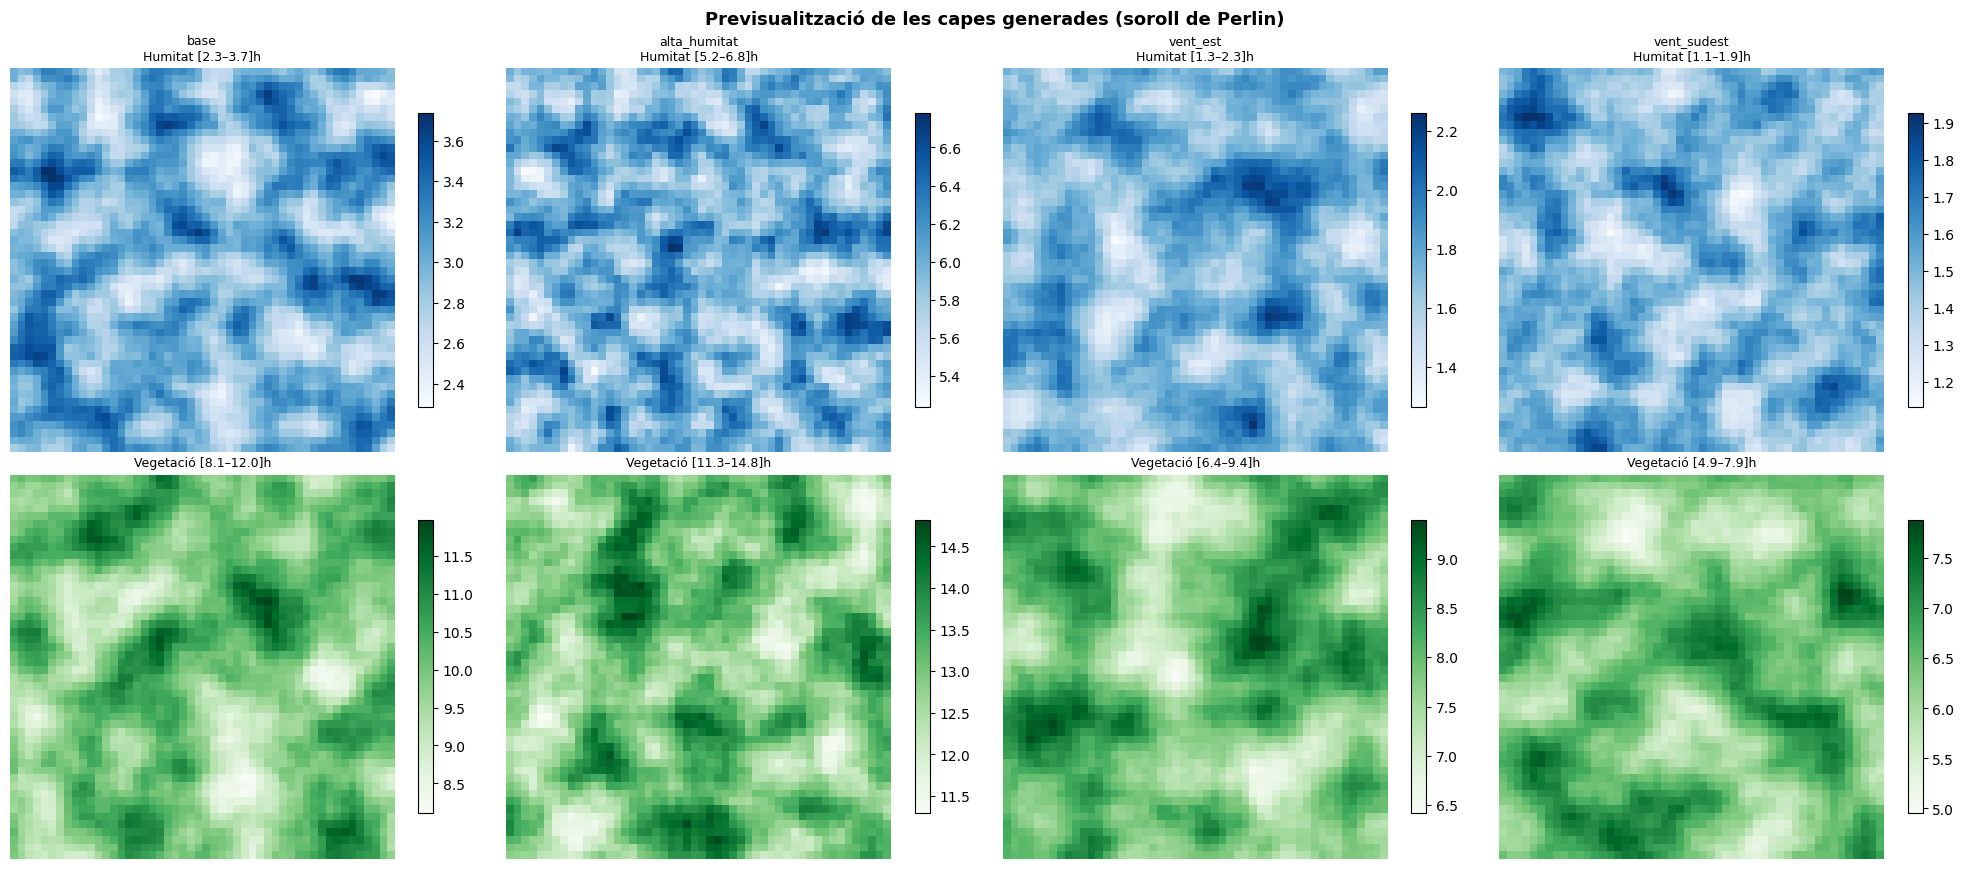

In [6]:
BASE_DIR = "dades"

for nom, cfg in ESCENARIS.items():
    esc_dir = os.path.join(BASE_DIR, nom)
    os.makedirs(esc_dir, exist_ok=True)
    print(f"\nEscenari '{nom}': {cfg['descripcio']}")

    # ── Genera les graelles amb soroll de Perlin ──────────────────
    hum_grid_gen = generate_layer(
        GRID_ROWS, GRID_COLS,
        value_min=cfg["hum_range"][0],
        value_max=cfg["hum_range"][1],
        scale=cfg["hum_scale"],
        seed=cfg["hum_seed"],
    )
    veg_grid_gen = generate_layer(
        GRID_ROWS, GRID_COLS,
        value_min=cfg["veg_range"][0],
        value_max=cfg["veg_range"][1],
        scale=cfg["veg_scale"],
        seed=cfg["veg_seed"],
    )

    # ── Escriu els fitxers IDRISI32 ───────────────────────────────
    write_idrisi32_layer(
        os.path.join(esc_dir, "humidity.doc"),
        os.path.join(esc_dir, "humidity.img"),
        hum_grid_gen,
        title=f"Humidity — {nom}",
        value_units="hours",
        value_label="Humidity delay before ignition",
    )
    write_idrisi32_layer(
        os.path.join(esc_dir, "vegetation.doc"),
        os.path.join(esc_dir, "vegetation.img"),
        veg_grid_gen,
        title=f"Vegetation — {nom}",
        value_units="hours",
        value_label="Burn duration",
    )
    write_idrisi31_wind(
        os.path.join(esc_dir, "wind.dvc"),
        os.path.join(esc_dir, "wind.vec"),
        cfg["wind_vector"],
    )

print("\nTots els fitxers generats correctament.")
print("   Ara pots executar l'Apartat 2 per simular qualsevol escenari.")

# ── Previsualització de les capes generades ─────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, len(ESCENARIS), figsize=(5 * len(ESCENARIS), 9))
fig.suptitle("Previsualització de les capes generades (soroll de Perlin)",
             fontsize=13, fontweight='bold')

for col, (nom, cfg) in enumerate(ESCENARIS.items()):
    esc_dir = os.path.join(BASE_DIR, nom)

    # Rellegim els fitxers per verificar que s'han escrit bé
    def read_img(path_img, rows, cols):
        vals = []
        with open(path_img) as f:
            for line in f:
                v = line.strip()
                if v: vals.append(float(v))
        grid = np.array(vals).reshape(rows, cols)
        return grid

    hg = read_img(os.path.join(esc_dir, "humidity.img"),   GRID_ROWS, GRID_COLS)
    vg = read_img(os.path.join(esc_dir, "vegetation.img"), GRID_ROWS, GRID_COLS)

    im0 = axes[0, col].imshow(hg, cmap="Blues")
    axes[0, col].set_title(f"{nom}\nHumitat [{hg.min():.1f}–{hg.max():.1f}]h", fontsize=9)
    axes[0, col].axis('off')
    plt.colorbar(im0, ax=axes[0, col], shrink=0.7)

    im1 = axes[1, col].imshow(vg, cmap="Greens")
    axes[1, col].set_title(f"Vegetació [{vg.min():.1f}–{vg.max():.1f}]h", fontsize=9)
    axes[1, col].axis('off')
    plt.colorbar(im1, ax=axes[1, col], shrink=0.7)

plt.tight_layout()
plt.show()

---
# APARTAT 2: SIMULACIÓ DE PROPAGACIÓ D'INCENDI

Aquest apartat llegeix els fitxers generats a l'Apartat 1 i executa la simulació.

**Com usar-lo:**
1. A la cel·la de configuració de simulació, tria l'escenari (`ESCENARI_SELECCIONAT`)
2. Configura els focus d'ignició (`IGNITE_CELLS`) — pots posar-ne més d'un per simular incendis múltiples simultanis
3. Executa la resta de cel·les en ordre

**Cada experiment mostra:**
- Visualització de les capes inicials (humitat + vegetació)
- Gràfic del grid de propagació en els passos clau
- Gràfiques de tendència temporal (cel·les per estat + % territori cremat)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import json

# ─────────────────────────────────────────────────────────
#  ESTATS DE LES CEL·LES
# ─────────────────────────────────────────────────────────
class CellState:
    EMPTY   = 0   # pendent de cremar (vegetació sana)
    MOIST   = 1   # eliminant humitat (retard de l'enunciat)
    BURNING = 2   # cremant → propaga foc als veïns
    BURNED  = 3   # cremat (vegetació consumida)

# ─────────────────────────────────────────────────────────
#  CONFIGURACIÓ DE LA SIMULACIÓ
#
#  Canvia ESCENARI_SELECCIONAT per provar altres escenaris.
#  Canvia IGNITE_CELLS per afegir múltiples focus d'ignició.
# ─────────────────────────────────────────────────────────

ESCENARI_SELECCIONAT = "base"   # opcions: base | alta_humitat | vent_est | vent_sudest

# Focus d'ignició: llista de tuples (fila, columna).
# Un únic focus central:
IGNITE_CELLS = [(25, 25)]

# Exemple amb múltiples focus (descomenta per provar-ho):
# IGNITE_CELLS = [(10, 10), (40, 40), (10, 40)]

# Mida de la graella de simulació
GRID_ROWS = 50
GRID_COLS = 50

# Nombre màxim de passos de simulació
MAX_STEPS = 80

# ─────────────────────────────────────────────────────────
#  COLORS I LLEGENDA
# ─────────────────────────────────────────────────────────
CMAP_COLORS = ["#639922", "#F4C0D1", "#EF9F27", "#444441"]
CMAP = mcolors.ListedColormap(CMAP_COLORS)
NORM = mcolors.BoundaryNorm([0, 1, 2, 3, 4], CMAP.N)
LEGEND_PATCHES = [
    mpatches.Patch(color=CMAP_COLORS[0], label="Vegetació (sana)"),
    mpatches.Patch(color=CMAP_COLORS[1], label="Escalfant-se (humitat)"),
    mpatches.Patch(color=CMAP_COLORS[2], label="En flames"),
    mpatches.Patch(color=CMAP_COLORS[3], label="Cremada"),
]
# Colors RGB per als fotogrames
COLOR_MAP_RGB = {
    CellState.EMPTY:   [60, 160, 60],
    CellState.MOIST:   [244, 192, 209],
    CellState.BURNING: [239, 159, 39],
    CellState.BURNED:  [50, 50, 50],
}

print(f"Escenari seleccionat: '{ESCENARI_SELECCIONAT}'")
print(f"Focus d'ignició     : {IGNITE_CELLS}")
print(f"Graella             : {GRID_ROWS}×{GRID_COLS}")
print(f"Passos màxims       : {MAX_STEPS}")

Escenari seleccionat: 'base'
Focus d'ignició     : [(25, 25)]
Graella             : 50×50
Passos màxims       : 80


## 1. Lectura de fitxers IDRISI32 — Capa d'Humitat

Els fitxers `humidity.doc` (capcalera) i `humidity.img` (dades) segueixen el format IDRISI32 ASCII.
- El `.doc` conte metadades: titol, mides, rang de valors, etc.
- El `.img` conte valors numerics d'humitat (hores de retard).

In [8]:
def parse_idrisi_doc(path):
    """Llegeix una capcalera IDRISI32 (.doc) -> dict clau:valor."""
    meta = {}
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if ":" in line:
                key, _, val = line.partition(":")
                meta[key.strip().lower()] = val.strip()
    return meta


def parse_idrisi_img_ascii(path):
    """Llegeix un fitxer de dades IDRISI32 ASCII -> llista de valors (string)."""
    values = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            v = line.strip()
            if v:
                values.append(v)
    return values


def build_numeric_grid(values, rows, cols, default_value=0.0):
    """Construeix una graella numerica rows x cols a partir d'una llista de valors."""
    n = len(values)
    grid = np.zeros((rows, cols), dtype=float)
    for r in range(rows):
        for c in range(cols):
            raw = values[(r * cols + c) % n] if n else default_value
            try:
                grid[r, c] = float(raw)
            except ValueError:
                grid[r, c] = float(default_value)
    return grid


# --- Carrega dels fitxers de l'escenari seleccionat ---
esc_dir = os.path.join("dades", ESCENARI_SELECCIONAT)

path_hdoc = os.path.join(esc_dir, "humidity.doc")
path_himg = os.path.join(esc_dir, "humidity.img")

for p in [path_hdoc, path_himg]:
    if not os.path.isfile(p):
        raise FileNotFoundError(
            f"Fitxer no trobat: {p}\n"
            "Executa primer l'Apartat 1 (generacio de fitxers)."
        )

hum_meta  = parse_idrisi_doc(path_hdoc)
hum_vals  = parse_idrisi_img_ascii(path_himg)

ROWS = GRID_ROWS
COLS = GRID_COLS
HUM_MIN = float(hum_meta.get("min. value", 0))
HUM_MAX = float(hum_meta.get("max. value", 2))

hum_grid = build_numeric_grid(
    hum_vals, ROWS, COLS,
    default_value=round((HUM_MIN + HUM_MAX) / 2, 1)
)

print(f"humidity.doc — '{hum_meta.get('file title', '')}'")
print(f"   Graella  : {ROWS} files x {COLS} columnes")
print(f"   Rang     : [{HUM_MIN}, {HUM_MAX}] hores")

humidity.doc — 'Humidity — base'
   Graella  : 50 files x 50 columnes
   Rang     : [2.2861, 3.7359] hores


## 2. Lectura de fitxers IDRISI32 — Capa de Vegetacio

Els fitxers `vegetation.doc` (capcalera) i `vegetation.img` (dades) segueixen el format IDRISI32 ASCII.
La capa conté valors numerics (hores de combustio).

In [9]:
def parse_wind_dvc(path):
    """Llegeix la direccio del vent del fitxer .dvc (opcional)."""
    meta = parse_idrisi_doc(path)
    dr = float(meta.get("wind dr", 0))
    dc = float(meta.get("wind dc", 0))
    return (int(dr), int(dc))


# --- Carrega de vegetacio i vent ---
path_vdoc = os.path.join(esc_dir, "vegetation.doc")
path_vimg = os.path.join(esc_dir, "vegetation.img")
path_wdvc = os.path.join(esc_dir, "wind.dvc")

for p in [path_vdoc, path_vimg]:
    if not os.path.isfile(p):
        raise FileNotFoundError(
            f"Fitxer no trobat: {p}\n"
            "Executa primer l'Apartat 1 (generacio de fitxers)."
        )

veg_meta = parse_idrisi_doc(path_vdoc)
veg_vals = parse_idrisi_img_ascii(path_vimg)

VEG_MIN = float(veg_meta.get("min. value", 0))
VEG_MAX = float(veg_meta.get("max. value", 10))

veg_grid = build_numeric_grid(
    veg_vals, ROWS, COLS,
    default_value=round((VEG_MIN + VEG_MAX) / 2, 1)
)

if os.path.isfile(path_wdvc):
    WIND_DIR = parse_wind_dvc(path_wdvc)
else:
    WIND_DIR = (0, 0)

print(f"vegetation.doc — '{veg_meta.get('file title', '')}'")
print(f"   Rang     : [{VEG_MIN}, {VEG_MAX}] hores")
print(f"   Vent: {WIND_DIR}")

vegetation.doc — 'Vegetation — base'
   Rang     : [8.1037, 11.9725] hores
   Vent: (0, 0)


## 3. Construcció de les capes

Construïm les dues capes d'entrada (humitat i vegetació) i mostrem les seves estadístiques.

In [10]:
# (cel·la buida reservada)

In [11]:
print(f"Graella {ROWS}x{COLS} construida")
print(f"   Humitat    min/max: {hum_grid.min():.2f} / {hum_grid.max():.2f} hores")
print(f"   Vegetacio  min/max: {veg_grid.min():.1f} / {veg_grid.max():.1f} hores")
print(f"   Focus d'ignicio   : {IGNITE_CELLS}")
print(f"   Direccio del vent : {WIND_DIR}")

Graella 50x50 construida
   Humitat    min/max: 2.29 / 3.74 hores
   Vegetacio  min/max: 8.1 / 12.0 hores
   Focus d'ignicio   : [(25, 25)]
   Direccio del vent : (0, 0)


## 4. Visualització de les capes inicials

Les estrelles vermelles (*) indiquen els focus d'ignició inicials.

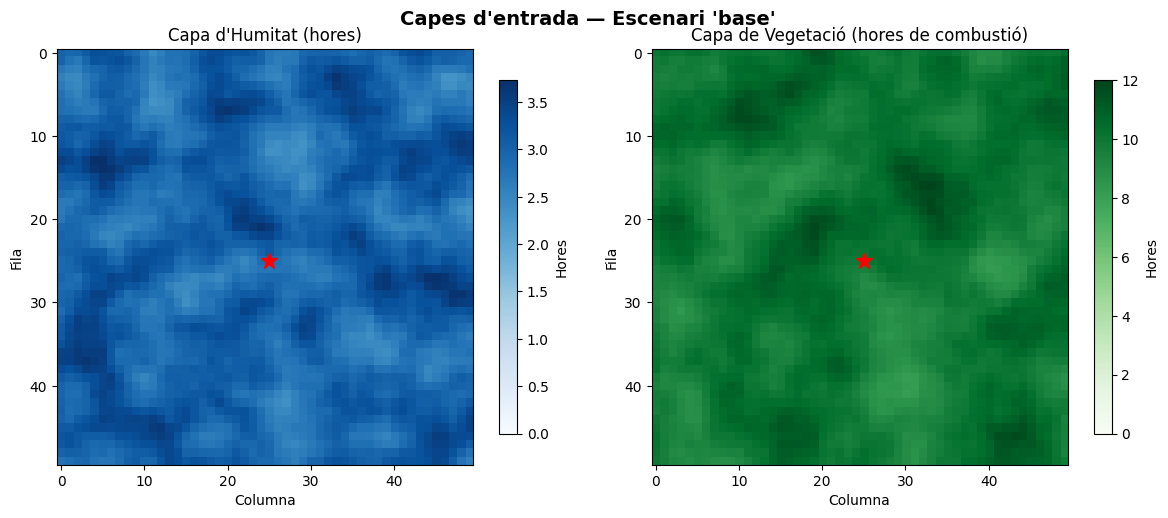

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Capes d'entrada — Escenari '{ESCENARI_SELECCIONAT}'", fontsize=14, fontweight='bold')

im0 = axes[0].imshow(hum_grid, cmap="Blues", vmin=0, vmax=max(2, hum_grid.max()))
axes[0].set_title("Capa d'Humitat (hores)")
axes[0].set_xlabel("Columna"); axes[0].set_ylabel("Fila")
plt.colorbar(im0, ax=axes[0], shrink=0.85, label="Hores")
for (r, c) in IGNITE_CELLS:
    axes[0].plot(c, r, 'r*', markersize=12)

im1 = axes[1].imshow(veg_grid, cmap="Greens", vmin=0, vmax=max(12, veg_grid.max()))
axes[1].set_title("Capa de Vegetació (hores de combustió)")
axes[1].set_xlabel("Columna"); axes[1].set_ylabel("Fila")
plt.colorbar(im1, ax=axes[1], shrink=0.85, label="Hores")
for (r, c) in IGNITE_CELLS:
    axes[1].plot(c, r, 'r*', markersize=12)

plt.tight_layout()
plt.show()

## 5. Model m:n-CA^k — Autòmat Cel·lular

### Regles de transició

| Estat actual | Condició | Estat següent |
|---|---|---|
| `EMPTY` | Veí cremant + humitat > 0 | `MOIST` (comença a escalfar-se) |
| `EMPTY` | Veí cremant + humitat = 0 | `BURNING` (s'encén directament) |
| `MOIST` | `hum_timer` ≥ `humitat_inicial` | `BURNING` (humitat esgotada) |
| `BURNING` | `burn_timer` > `vegetació_inicial` | `BURNED` (vegetació consumida) |

### Efecte del vent

El vent s'implementa com un **bonus de pre-assecament**: quan una cel·la `BURNING` propaga el foc a un veí `EMPTY`, el `hum_timer` del veí s'inicialitza ja avançat en funció de l'alineació entre la direcció del vent i la direcció de propagació.

```
hum_timer_inicial = align(vent, direcció) × WIND_BONUS × hum_init
```

- **`WIND_BONUS = 0.0`** → el vent no té cap efecte
- **`WIND_BONUS = 0.6`** → valor recomanat: el vent modifica fins al ±60% del retard d'humitat
- **`WIND_BONUS = 1.0`** → efecte màxim: sense retard a favor, doble retard en contra

El vent actua **siméricament** en ambdues direccions:
- **A favor del vent** → `hum_timer` inicia avançat → la cel·la s'encén abans
- **Perpendicular** → cap efecte
- **En contra del vent** → `hum_timer` inicia en negatiu → la cel·la triga més a encendre's

El model continua sent **completament determinista**.

In [13]:
class WildfireCA:
    """
    Model m:n-CA^k per a la propagació d'un incendi forestal.

    Capes internes:
      state       : CellState de cada cel·la (EMPTY, MOIST, BURNING, BURNED)
      hum_init    : humitat inicial (hores) — capa estàtica d'entrada
      veg_init    : vegetació inicial (hores de combustió) — capa estàtica d'entrada
      burn_timer  : comptador de passos que la cel·la porta cremant
      hum_timer   : comptador de passos que la cel·la porta escalfant-se

    Efecte del vent (WIND_BONUS):
      Quan el vent bufa cap a un veí, el seu hum_timer s'inicialitza amb un bonus
      proporcional a l'alineació amb el vent. Físicament: el vent pre-asseca la cel·la
      receptora, reduint el temps que triga a encendre's. El model segueix sent
      completament determinista.

      WIND_BONUS = fracció de la humitat que el vent elimina d'un cop [0.0 – 1.0]:
        0.0 → el vent no té cap efecte
        0.5 → el vent elimina fins al 50% de la humitat en la seva direcció
        1.0 → les cel·les a favor del vent s'encenen immediatament (sense retard)
    """

    WIND_BONUS = 0.6   # ← ajusta aquí l'intensitat del vent (0.0 – 1.0)

    def __init__(self, humidity_grid, vegetation_grid, wind_dir=(0, 0)):
        self.rows, self.cols = humidity_grid.shape
        self.hum_init  = humidity_grid.copy().astype(float)
        self.veg_init  = vegetation_grid.copy().astype(float)
        self.wind_dir  = wind_dir
        self.max_veg   = max(1.0, float(np.max(vegetation_grid)))
        self.reset()

    def reset(self):
        """Reinicia totes les capes dinàmiques a l'estat inicial."""
        self.state      = np.full((self.rows, self.cols), CellState.EMPTY, dtype=int)
        self.burn_timer = np.zeros((self.rows, self.cols), dtype=float)
        self.hum_timer  = np.zeros((self.rows, self.cols), dtype=float)
        self.veg_cur    = self.veg_init.copy()
        self.step       = 0
        self.history    = []

    def ignite(self, row, col):
        """Encén manualment la cel·la (row, col) com a focus d'ignició inicial."""
        if 0 <= row < self.rows and 0 <= col < self.cols:
            self.state[row, col]      = CellState.BURNING
            self.burn_timer[row, col] = 0
            print(f"   Focus [{row:3d},{col:3d}]  veg={self.veg_init[row,col]:.0f}h  "
                  f"hum={self.hum_init[row,col]:.1f}h")

    def _wind_hum_bonus(self, dr, dc):
        """
        Calcula el bonus de hum_timer per al veí en direcció (dr, dc).

        Retorna un valor en [-WIND_BONUS, +WIND_BONUS]:
          > 0 → a favor del vent: el hum_timer comença avançat (menys retard)
          = 0 → perpendicular al vent: sense efecte
          < 0 → en contra del vent: el hum_timer comença en negatiu (més retard)

        Exemple amb WIND_BONUS=0.6 i hum_init=3h:
          - Directament a favor  (align= 1.0): timer inicia a +1.8 → triga 1.2 passos
          - Perpendicular        (align= 0.0): timer inicia a  0.0 → triga 3.0 passos
          - Directament en contra(align=-1.0): timer inicia a -1.8 → triga 4.8 passos
        """
        wr, wc = self.wind_dir
        if wr == 0 and wc == 0:
            return 0.0
        # Producte escalar normalitzat ∈ [-1, 1]
        dot  = dr * wr + dc * wc
        norm = (wr**2 + wc**2) ** 0.5 * (dr**2 + dc**2) ** 0.5
        align = dot / norm if norm > 0 else 0.0
        # align positiu = a favor, negatiu = en contra
        return align * self.WIND_BONUS

    def advance(self):
        """
        Executa un pas de l'autòmat cel·lular (determinista amb efecte de vent).

        Efecte del vent: quan una cel·la BURNING propaga a un veí EMPTY,
        el hum_timer del veí s'inicialitza amb un bonus proporcional a
        l'alineació vent-direcció. Això redueix el temps fins a BURNING.
        """
        new_state      = self.state.copy()
        new_burn_timer = self.burn_timer.copy()
        new_hum_timer  = self.hum_timer.copy()
        new_veg_cur    = self.veg_cur.copy()

        for r in range(self.rows):
            for c in range(self.cols):
                s = self.state[r, c]

                if s == CellState.BURNING:
                    new_burn_timer[r, c] += 1
                    new_veg_cur[r, c] = max(0.0,
                        self.veg_init[r, c] - new_burn_timer[r, c])

                    if new_burn_timer[r, c] > self.veg_init[r, c]:
                        new_state[r, c] = CellState.BURNED
                    else:
                        for dr in [-1, 0, 1]:
                            for dc in [-1, 0, 1]:
                                if dr == 0 and dc == 0:
                                    continue
                                nr, nc = r + dr, c + dc
                                if not (0 <= nr < self.rows and 0 <= nc < self.cols):
                                    continue
                                if self.state[nr, nc] != CellState.EMPTY:
                                    continue

                                # Bonus de vent: pre-asseca el veí en la direcció del vent
                                bonus = self._wind_hum_bonus(dr, dc)
                                hum_efectiva = self.hum_init[nr, nc]

                                if hum_efectiva <= 0:
                                    new_state[nr, nc]      = CellState.BURNING
                                    new_burn_timer[nr, nc] = 0
                                else:
                                    new_state[nr, nc] = CellState.MOIST
                                    # El hum_timer comença avançat pel bonus del vent
                                    new_hum_timer[nr, nc] = bonus * hum_efectiva

                elif s == CellState.MOIST:
                    new_hum_timer[r, c] += 1
                    if new_hum_timer[r, c] >= self.hum_init[r, c]:
                        new_state[r, c]      = CellState.BURNING
                        new_burn_timer[r, c] = 0

        self.state      = new_state
        self.burn_timer = new_burn_timer
        self.hum_timer  = new_hum_timer
        self.veg_cur    = new_veg_cur
        self.step      += 1
        self.history.append(self.state.copy())

    def render_rgb(self):
        """Retorna una imatge RGB amb gradient de color continu per estat i intensitat."""
        img = np.zeros((self.rows, self.cols, 3), dtype=np.uint8)
        for r in range(self.rows):
            for c in range(self.cols):
                s = self.state[r, c]
                if s == CellState.EMPTY:
                    ratio = min(1.0, self.veg_cur[r, c] / self.max_veg)
                    img[r, c] = [0, int(80 + ratio * 150), 0]
                elif s == CellState.MOIST:
                    img[r, c] = [244, 192, 209]
                elif s == CellState.BURNING:
                    ratio = 1.0 - min(1.0, self.veg_cur[r, c] / max(1, self.veg_init[r, c]))
                    img[r, c] = [255, int(200 * (1 - ratio)), 0]
                else:
                    img[r, c] = [50, 50, 50]
        return img

    def frame_rgb(self, state_grid):
        """Genera una imatge RGB a partir d'una capa d'estat (per als fotogrames)."""
        img = np.zeros((self.rows, self.cols, 3), dtype=np.uint8)
        for state, color in COLOR_MAP_RGB.items():
            img[state_grid == state] = color
        return img

    def stats(self):
        total   = self.rows * self.cols
        burning = int(np.sum(self.state == CellState.BURNING))
        moist   = int(np.sum(self.state == CellState.MOIST))
        burned  = int(np.sum(self.state == CellState.BURNED))
        safe    = total - burning - moist - burned
        return {"step": self.step, "burning": burning, "moist": moist,
                "burned": burned, "safe": safe, "total": total}

    def is_active(self):
        return (np.any(self.state == CellState.BURNING) or
                np.any(self.state == CellState.MOIST))


print(f"Classe WildfireCA definida (vent amb bonus d'humitat, WIND_BONUS={WildfireCA.WIND_BONUS}).")

Classe WildfireCA definida.


## 6. Execució de la simulació principal

Executa el model CA fins que s'extingeixi el foc o s'arribi al màxim de passos.

In [14]:
ca = WildfireCA(hum_grid, veg_grid, wind_dir=WIND_DIR)

print(f"Encenent {len(IGNITE_CELLS)} focus d'ignició:")
for (r, c) in IGNITE_CELLS:
    ca.ignite(r, c)

stats_history = []

print(f"\n{'Pas':>5}  {'Flames':>9}  {'Escalfant':>11}  {'Cremat':>9}  {'Sa':>7}  {'%Cremat':>8}")
print("-" * 62)

for _ in range(MAX_STEPS):
    if not ca.is_active():
        print("  → Foc extingit.")
        break
    ca.advance()
    s = ca.stats()
    stats_history.append(s)
    pct = s["burned"] / s["total"] * 100
    print(f"{s['step']:>5}  {s['burning']:>9}  {s['moist']:>11}  "
          f"{s['burned']:>9}  {s['safe']:>7}  {pct:>7.1f}%")

print("-" * 62)
sf = ca.stats()
print(f"\nResultat final — Pas {sf['step']}:")
print(f"   Cremat : {sf['burned']:5d} cel·les ({sf['burned']/sf['total']*100:.1f}%)")
print(f"   Sa     : {sf['safe']:5d} cel·les ({sf['safe']/sf['total']*100:.1f}%)")

Encenent 1 focus d'ignició:
   Focus [ 25, 25]  veg=10h  hum=2.9h

  Pas     Flames    Escalfant     Cremat       Sa   %Cremat
--------------------------------------------------------------
    1          1            8          0     2491      0.0%
    2          1            8          0     2491      0.0%
    3          1            8          0     2491      0.0%
    4          8            1          0     2491      0.0%
    5          9           16          0     2475      0.0%
    6          9           16          0     2475      0.0%
    7          9           16          0     2475      0.0%
    8         22            3          0     2475      0.0%
    9         25           21          0     2454      0.0%
   10         25           24          0     2451      0.0%
   11         24           24          1     2451      0.0%
   12         40            8          1     2451      0.0%
   13         45           28          1     2426      0.0%
   14         44           29 

## 7. Gràfiques d'evolució temporal

Mostrem dues gràfiques per a tota la simulació:
- **Esquerra**: nombre de cel·les per estat a cada pas (flames, escalfant-se, cremat, sa)
- **Dreta**: percentatge acumulat del territori cremat

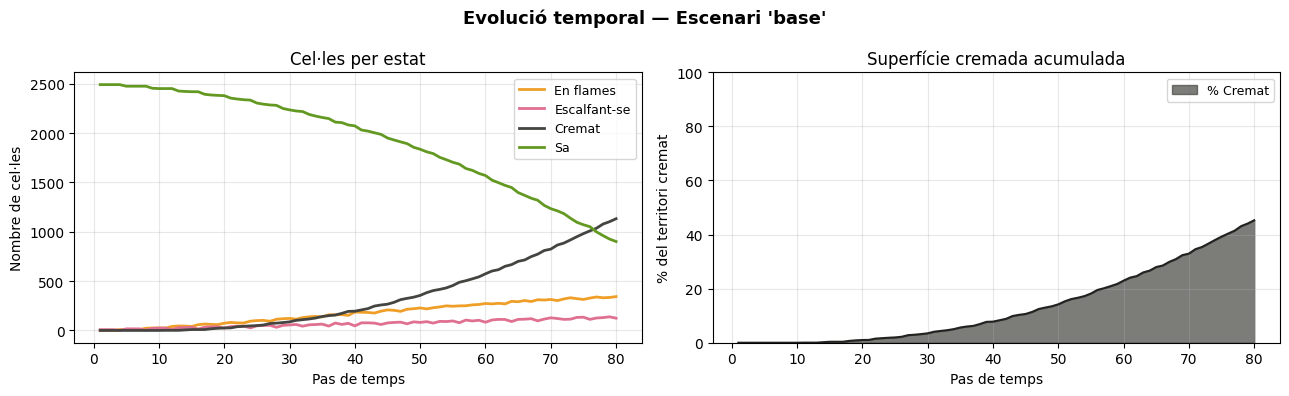

In [15]:
def plot_tendencies(stats_history, ca, title_suffix=""):
    """Dibuixa les gràfiques de tendència temporal de la simulació."""
    if not stats_history:
        print("Cap dada d'evolució disponible.")
        return

    steps   = [s["step"]    for s in stats_history]
    burning = [s["burning"] for s in stats_history]
    moist   = [s["moist"]   for s in stats_history]
    burned  = [s["burned"]  for s in stats_history]
    safe    = [s["safe"]    for s in stats_history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Evolució temporal{' — ' + title_suffix if title_suffix else ''}",
                 fontsize=13, fontweight='bold')

    ax1.plot(steps, burning, color="#EF9F27", lw=2, label="En flames")
    ax1.plot(steps, moist,   color="#E07090", lw=2, label="Escalfant-se")
    ax1.plot(steps, burned,  color="#444441", lw=2, label="Cremat")
    ax1.plot(steps, safe,    color="#639922", lw=2, label="Sa")
    ax1.set_xlabel("Pas de temps"); ax1.set_ylabel("Nombre de cel·les")
    ax1.set_title("Cel·les per estat")
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    pct_burned = [b / ca.rows / ca.cols * 100 for b in burned]
    ax2.fill_between(steps, pct_burned, color="#444441", alpha=0.7, label="% Cremat")
    ax2.plot(steps, pct_burned, color="#222220", lw=1.5)
    ax2.set_xlabel("Pas de temps"); ax2.set_ylabel("% del territori cremat")
    ax2.set_title("Superfície cremada acumulada")
    ax2.set_ylim(0, 100); ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


plot_tendencies(stats_history, ca, title_suffix=f"Escenari '{ESCENARI_SELECCIONAT}'")

## 8. Visualització del resultat final

Mostrem les tres capes juntes: humitat inicial, vegetació inicial i estat final de la propagació.
Les estrelles blanques marquen els focus d'ignició.

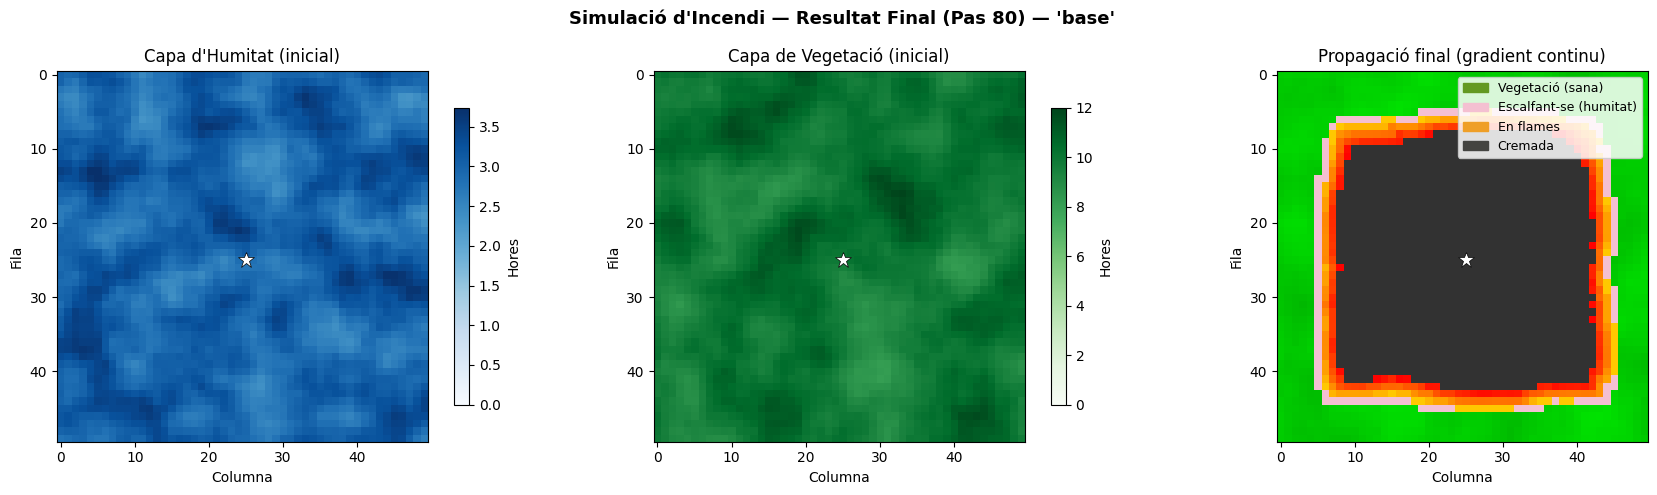

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Simulació d'Incendi — Resultat Final (Pas {ca.step}) — '{ESCENARI_SELECCIONAT}'",
             fontsize=13, fontweight='bold')

im0 = axes[0].imshow(hum_grid, cmap="Blues", vmin=0, vmax=max(2, hum_grid.max()))
axes[0].set_title("Capa d'Humitat (inicial)")
axes[0].set_xlabel("Columna"); axes[0].set_ylabel("Fila")
plt.colorbar(im0, ax=axes[0], shrink=0.8, label="Hores")

im1 = axes[1].imshow(veg_grid, cmap="Greens", vmin=0, vmax=max(12, veg_grid.max()))
axes[1].set_title("Capa de Vegetació (inicial)")
axes[1].set_xlabel("Columna"); axes[1].set_ylabel("Fila")
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Hores")

axes[2].imshow(ca.render_rgb())
axes[2].set_title("Propagació final (gradient continu)")
axes[2].set_xlabel("Columna"); axes[2].set_ylabel("Fila")
axes[2].legend(handles=LEGEND_PATCHES, loc="upper right", fontsize=9, framealpha=0.85)

for ax in axes:
    for (r, c) in IGNITE_CELLS:
        ax.plot(c, r, 'w*', markersize=12, markeredgecolor='black', markeredgewidth=0.5)

plt.tight_layout()
plt.show()

## 9. Fotogrames de la propagació

Mostrem 12 instantànies de la simulació distribuïdes uniformement en el temps.

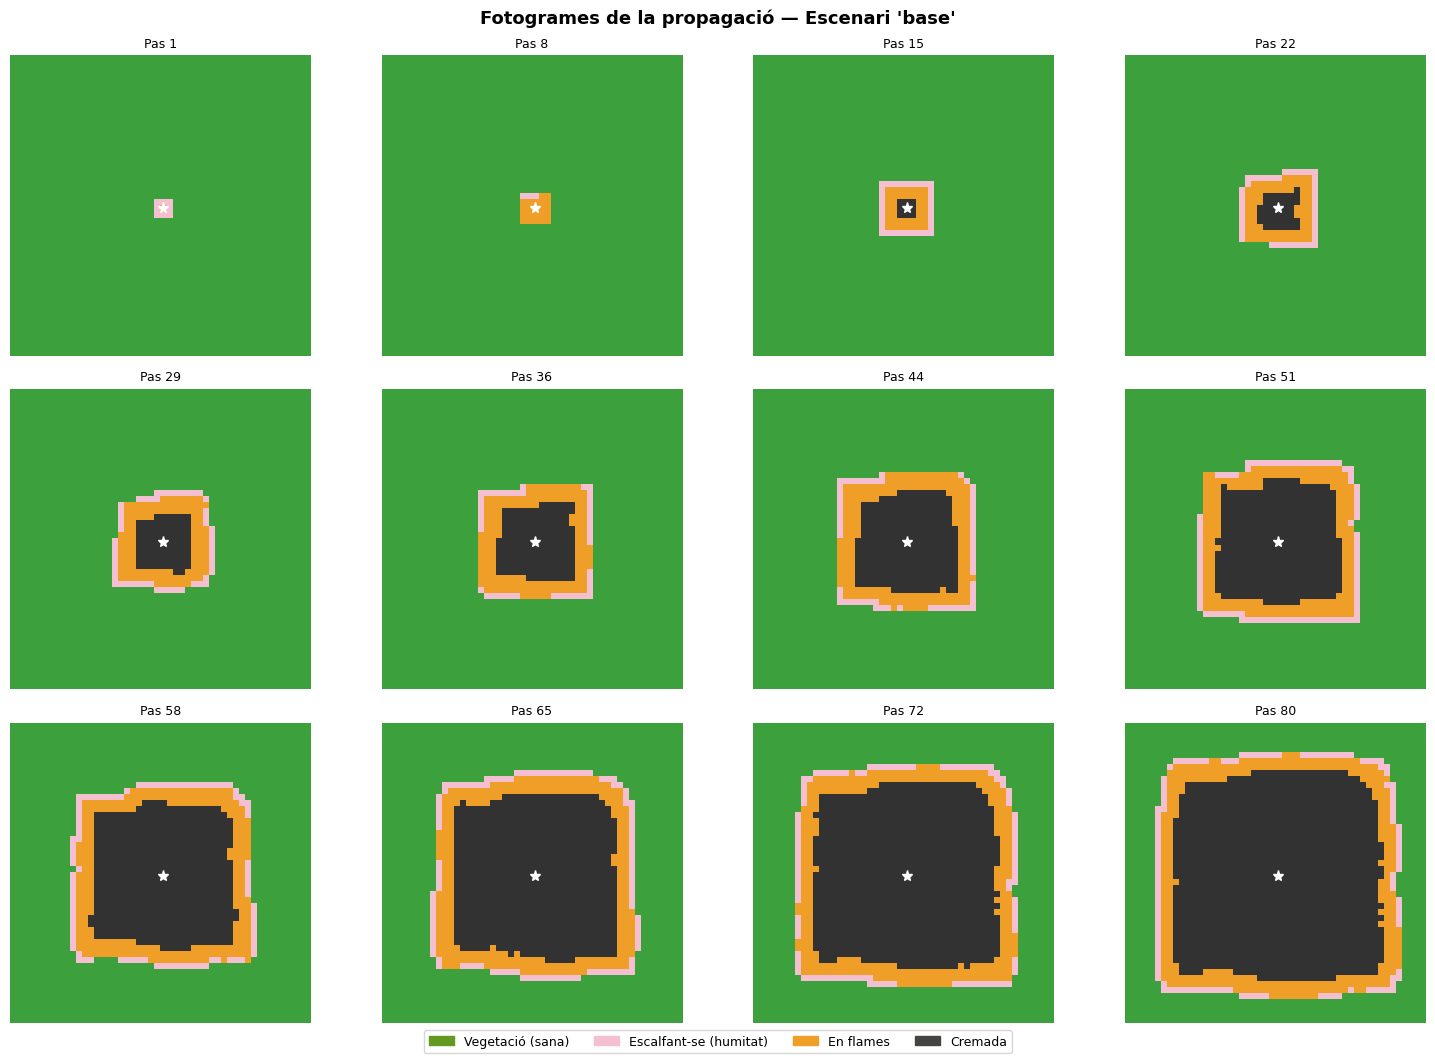

In [17]:
def plot_frames(ca, ignite_cells, title_suffix=""):
    """Dibuixa una graella de fotogrames de la propagació de l'incendi."""
    if not ca.history:
        print("Cap historial disponible.")
        return

    n_frames = len(ca.history)
    indices  = np.linspace(0, n_frames - 1, min(12, n_frames), dtype=int)

    ncols = 4
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.8, nrows * 3.5))
    axes = axes.flatten()
    fig.suptitle(
        f"Fotogrames de la propagació{' — ' + title_suffix if title_suffix else ''}",
        fontsize=13, fontweight='bold'
    )

    for i, idx in enumerate(indices):
        frame = ca.history[idx]
        img = np.zeros((ca.rows, ca.cols, 3), dtype=np.uint8)
        for state, color in COLOR_MAP_RGB.items():
            img[frame == state] = color
        axes[i].imshow(img)
        axes[i].set_title(f"Pas {idx + 1}", fontsize=9)
        axes[i].axis('off')
        for (r, c) in ignite_cells:
            axes[i].plot(c, r, 'w*', markersize=8)

    for j in range(len(indices), len(axes)):
        axes[j].axis('off')

    fig.legend(handles=LEGEND_PATCHES, loc='lower center',
               ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()


plot_frames(ca, IGNITE_CELLS, title_suffix=f"Escenari '{ESCENARI_SELECCIONAT}'",)

### Anàlisi de resultats — Escenari base

L'escenari base simula la propagació d'un únic focus d'ignició ubicat al centre de la graella (fila 25, columna 25) sobre un terreny homogeni de bosc mediterrani, sense vent i amb humitat en el rang [1.0, 5.0] hores i vegetació en el rang [5.0, 15.0] hores.

**Dinàmica temporal** 

Les gràfiques d'evolució mostren un creixement gairebé simètric i continu. El nombre de cel·les en flames assoleix aviat un valor de l'ordre de 300–350 unitats i s'hi manté aproximadament constant al llarg de la simulació. Això no significa que el foc s'extingeixi ni que el front s'aturi: reflecteix un quasi-equilibri dinàmic en el qual el ritme d'encesa de noves cel·les (transicions MOIST - BURNING des del front extern) i el ritme de consumició (transicions BURNING - BURNED al nucli intern) es compensen aproximadament a cada pas. Mentre aquest equilibri es manté, el front avança contínuament i la superfície cremada creix. El nombre de cel·les en procés d'escalfament (MOIST) es manté baix durant tot el recorregut, la qual cosa indica que el retard d'humitat del model base no és suficientment elevat per acumular un gran nombre de cel·les pendents d'encendre's de forma simultània. La corba de cel·les cremades creix de manera accelerada a partir del pas 40, moment en que el front de foc ha guanyat prou amplada per incidir sobre un nombre creixent de cel·les noves a cada pas.

**Resultat final (pas 80)** 

Al final de la simulació, aproximadament el **45% del territori** ha quedat cremat, mentre que prop d'un **38% segueix sa**. La resta correspon a cel·les actives (en flames o escalfant-se) en el moment de finalitzar la simulació. El foc no s'ha extingit: el front continua actiu al pas 80 perquè no ha assolit cap vora de la graella en la majoria de direccions.

**Mapa de propagació** 

La seqüència de fotogrames confirma la progressió circular des del centre cap a l'exterior. La forma aproximadament quadrada del front, visible a partir del pas 22, reflecteix el veïnatge de Moore (8 veïns): la diagonal es propaga lleugerament més ràpid que els eixos ortogonals a causa de la major quantitat de frontera exposada. Les zones amb humitat localment elevada (visibles a la capa d'humitat com a taques blau fosc) provoquen lleugeres concavitats en el front, de manera que la propagació no és perfectament circular sinó que s'adapta a la heterogeneïtat del terreny.

**Conclusió** 

L'escenari base estableix el comportament de referència del model: propagació contínua, expansió radial i un ritme de crema moderat. Serà la base de comparació per als experiments posteriors.


---
# EXPERIMENTS

A continuació es presenten tres experiments independents, cadascun amb les seves gràfiques d'evolució temporal i fotogrames de propagació.

**Tots els experiments comparteixen la mateixa funció auxiliar `run_experiment`**, que:
1. Inicialitza el model CA amb les capes i paràmetres indicats
2. Executa la simulació fins a l'extinció o el màxim de passos
3. Mostra el grid final + gràfiques de tendència + fotogrames

In [18]:
def run_experiment(label, hum_grid, veg_grid, ignite_cells, wind_dir=(0, 0),
                   max_steps=80):
    """
    Executa un experiment complet de simulació d'incendi i mostra tots els gràfics.

    Paràmetres:
      label        : nom descriptiu de l'experiment (per als títols)
      hum_grid     : graella d'humitat (numpy array)
      veg_grid     : graella de vegetació (numpy array)
      ignite_cells : llista de tuples (fila, columna) dels focus d'ignició
      wind_dir     : tuple (dr, dc) — direcció del vent
      max_steps    : nombre màxim de passos

    Retorna el model WildfireCA amb l'historial complet.
    """
    nom_vent = {(0,0): "sense vent", (0,1): "est", (0,-1): "oest",
                (1,0): "sud", (-1,0): "nord", (1,1): "sud-est",
                (-1,-1): "nord-oest", (1,-1): "sud-oest", (-1,1): "nord-est"}
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {label}")
    print(f"  Focus d'ignició : {ignite_cells}")
    print(f"  Vent            : {wind_dir} ({nom_vent.get(wind_dir, str(wind_dir))})")
    print(f"{'='*60}")

    ca_exp = WildfireCA(hum_grid, veg_grid, wind_dir=wind_dir)

    for (r, c) in ignite_cells:
        ca_exp.ignite(r, c)

    sh = []
    for _ in range(max_steps):
        if not ca_exp.is_active():
            print("  → Foc extingit.")
            break
        ca_exp.advance()
        sh.append(ca_exp.stats())

    sf = ca_exp.stats()
    print(f"\n  Resultat final — Pas {sf['step']}:")
    print(f"    Cremat : {sf['burned']:5d} cel·les ({sf['burned']/sf['total']*100:.1f}%)")
    print(f"    Sa     : {sf['safe']:5d} cel·les ({sf['safe']/sf['total']*100:.1f}%)")

    # ── Grid final ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{label} — Resultat Final (Pas {ca_exp.step})",
                 fontsize=13, fontweight='bold')
    im0 = axes[0].imshow(hum_grid, cmap="Blues", vmin=0, vmax=max(2, hum_grid.max()))
    axes[0].set_title("Humitat inicial")
    plt.colorbar(im0, ax=axes[0], shrink=0.8, label="Hores")
    im1 = axes[1].imshow(veg_grid, cmap="Greens", vmin=0, vmax=max(12, veg_grid.max()))
    axes[1].set_title("Vegetació inicial")
    plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Hores")
    axes[2].imshow(ca_exp.render_rgb())
    axes[2].set_title("Propagació final")
    axes[2].legend(handles=LEGEND_PATCHES, loc="upper right", fontsize=9, framealpha=0.85)
    for ax in axes:
        ax.set_xlabel("Columna"); ax.set_ylabel("Fila")
        for (r2, c2) in ignite_cells:
            ax.plot(c2, r2, 'w*', markersize=12, markeredgecolor='black', markeredgewidth=0.5)
    plt.tight_layout(); plt.show()

    # ── Gràfiques de tendència ────────────────────────────────────────────────
    plot_tendencies(sh, ca_exp, title_suffix=label)

    # ── Fotogrames ────────────────────────────────────────────────────────────
    plot_frames(ca_exp, ignite_cells, title_suffix=label)

    return ca_exp, sh


print("Funció run_experiment definida.")

Funció run_experiment definida.


## Experiment 1: Múltiples focus d'ignició simultanis

Simulem un incendi amb **tres focus d'ignició simultanis** (un central i dos als extrems).
Esperem que els fronts de foc creixents acabin fusionant-se, accelerant la propagació total.


EXPERIMENT: Exp.1 — Múltiples focus (central + 2 extrems)
  Focus d'ignició : [(25, 25), (5, 5), (44, 44)]
  Vent            : (0, 0) (sense vent)
   Focus [ 25, 25]  veg=10h  hum=2.9h
   Focus [  5,  5]  veg=10h  hum=3.1h
   Focus [ 44, 44]  veg=11h  hum=3.2h

  Resultat final — Pas 80:
    Cremat :  1721 cel·les (68.8%)
    Sa     :   446 cel·les (17.8%)


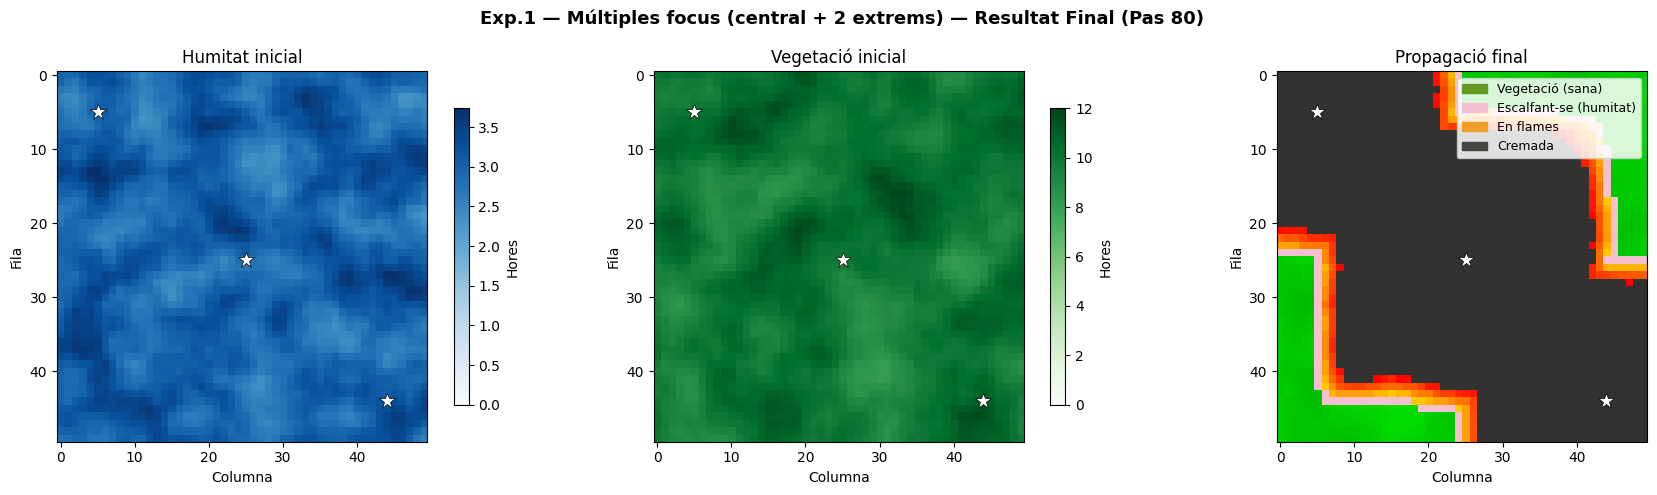

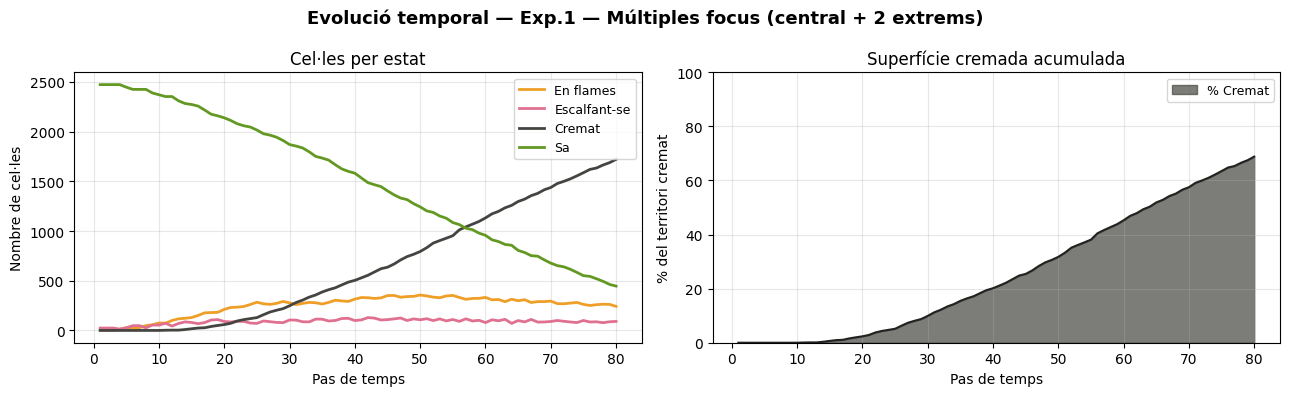

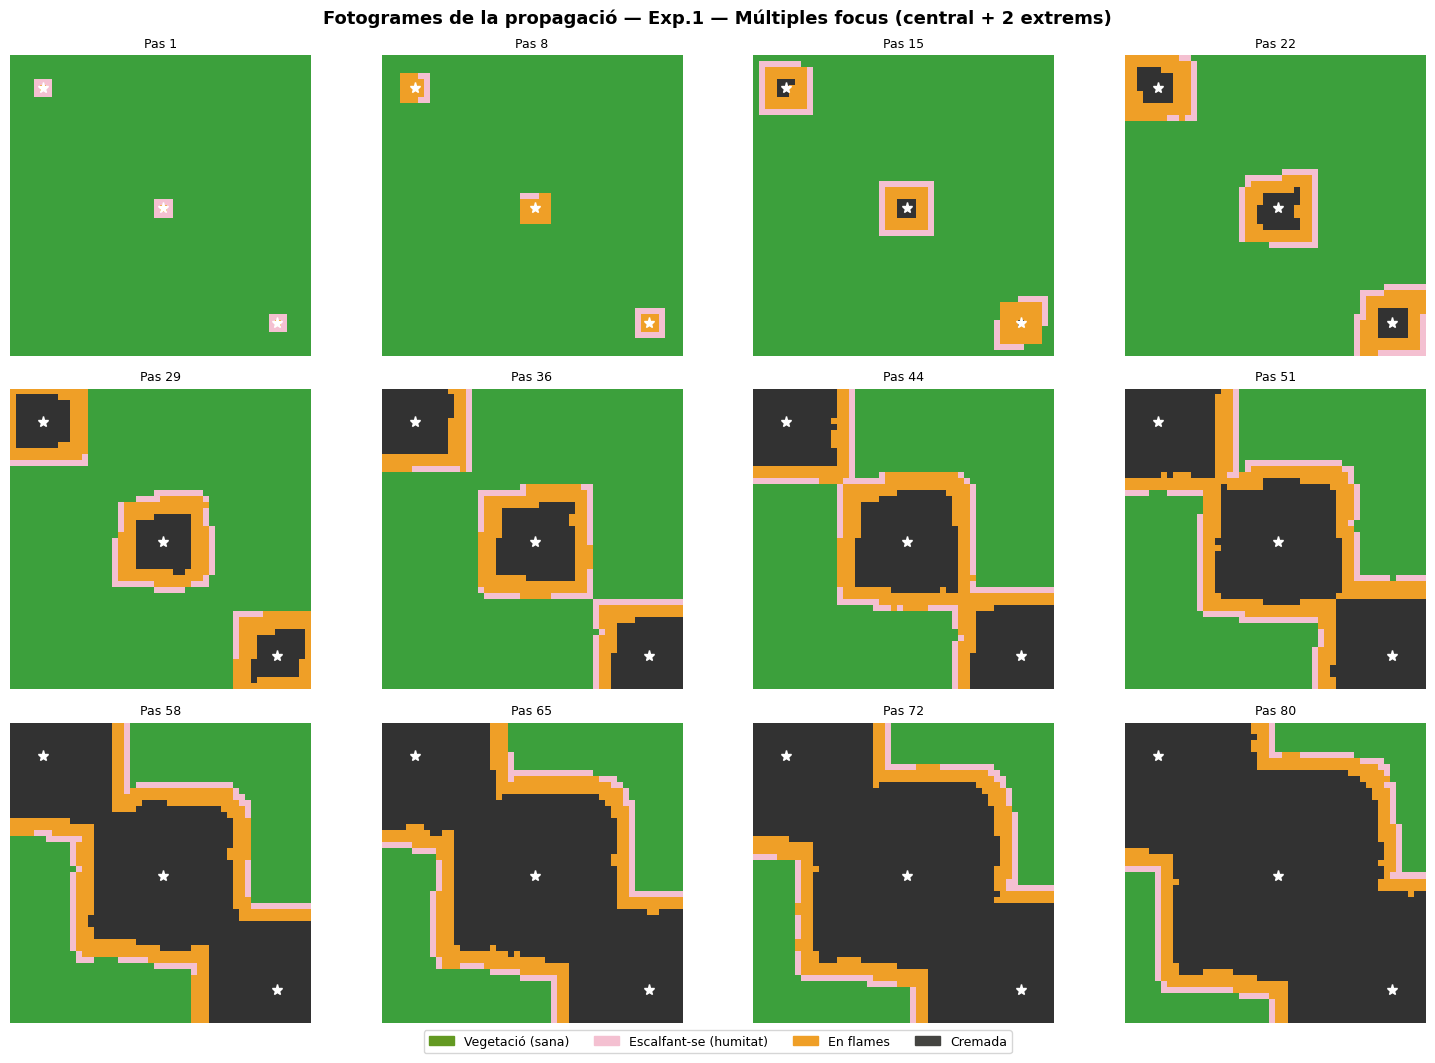

In [19]:
# Experiment 1: tres focus d'ignició simultanis
# Usem el l'escenari 'base' (ja carregat a hum_grid / veg_grid)

ca_exp1, sh1 = run_experiment(
    label="Exp.1 — Múltiples focus (central + 2 extrems)",
    hum_grid=hum_grid,
    veg_grid=veg_grid,
    ignite_cells=[(25, 25), (5, 5), (44, 44)],   # focus central + dos extrems
    wind_dir=(0, 0),
    max_steps=MAX_STEPS,
)

### Anàlisi de resultats — Experiment 1: múltiples focus d'ignició

L'experiment 1 repeteix les mateixes capes d'humitat i vegetació de l'escenari base (sense vent), però introdueix **tres focus d'ignició simultanis**: un al centre (25, 25) i dos als extrems (5, 5) i (44, 44), situats a les cantonades superior esquerra i inferior dreta, respectivament.

**Increment de la superfície cremada** 

Al final de la simulació (pas 80), **1.721 cel·les han cremat (68,8%)**, enfront del 45% de l'escenari base amb un sol focus. Aquest increment del 24 punts percentuals il·lustra l'efecte multiplicador dels fronts paral·lels: mentre el focus central repeteix el comportament de l'escenari base, els dos focus extrems encenen el foc des de les vores, on ja no hi ha cel·les veïnes en la direcció exterior i, per tant, tota la propagació és cap a l'interior. Això redueix el temps fins a la fusió dels fronts.

**Fusió dels fronts** 

Les gràfiques temporals mostren que la corba de cel·les *en flames* s'eleva de forma significativa entre els passos 10 i 30, reflex de la contribució simultània dels tres focus. A partir del pas 40–50, els fronts del focus central i dels extrems s'aproximen i comencen a fusionar-se, la qual cosa es manifesta com una lleugera davallada de la corba *en flames*: quan dos fronts actius es troben, les cel·les de la zona de contacte ja estan en estat MOIST o BURNING des d'ambdós costats i deixen d'afegir noves cel·les al front. La caiguda de la corba *Sa* és notablement més pronunciada i anticipada respecte a l'escenari base.

**Mapa de propagació** 

Els fotogrames confirmen la triple expansió independent durant els primers passos. A partir del pas 51–58 es fa visible la fusió entre el focus central i el de la cantonada inferior dreta, mentre que el focus de la cantonada superior esquerra arriba a la vora esquerra de la graella cap al pas 29. Al pas 80, la zona cremada forma una gran àrea connectada que ocupa la major part de la graella, deixant únicament les cantonades superior dreta i inferior esquerra parcialment intactes.

**Conclusió parcial** 

Múltiples focus d'ignició no sumen linealment els seus efectes: la fusió dels fronts genera una sinergia que accelera significativament la propagació global. En un context real, això té implicacions directes per a la planificació de recursos d'extinció, ja que la coordinació simultània de diversos flancs actius incrementa de manera no proporcional la superfície afectada.


## Experiment 2: Comparació de focus únics vs. múltiples en escenari d'alta humitat

Comparem l'efecte de tenir un únic focus central versus quatre focus als quatre cantons,
en el **escenari d'alta humitat** (propagació molt més lenta).


EXPERIMENT: Exp.2a — Alta humitat, 1 focus central
  Focus d'ignició : [(25, 25)]
  Vent            : (0, 0) (sense vent)
   Focus [ 25, 25]  veg=13h  hum=5.7h

  Resultat final — Pas 80:
    Cremat :   343 cel·les (13.7%)
    Sa     :  1910 cel·les (76.4%)


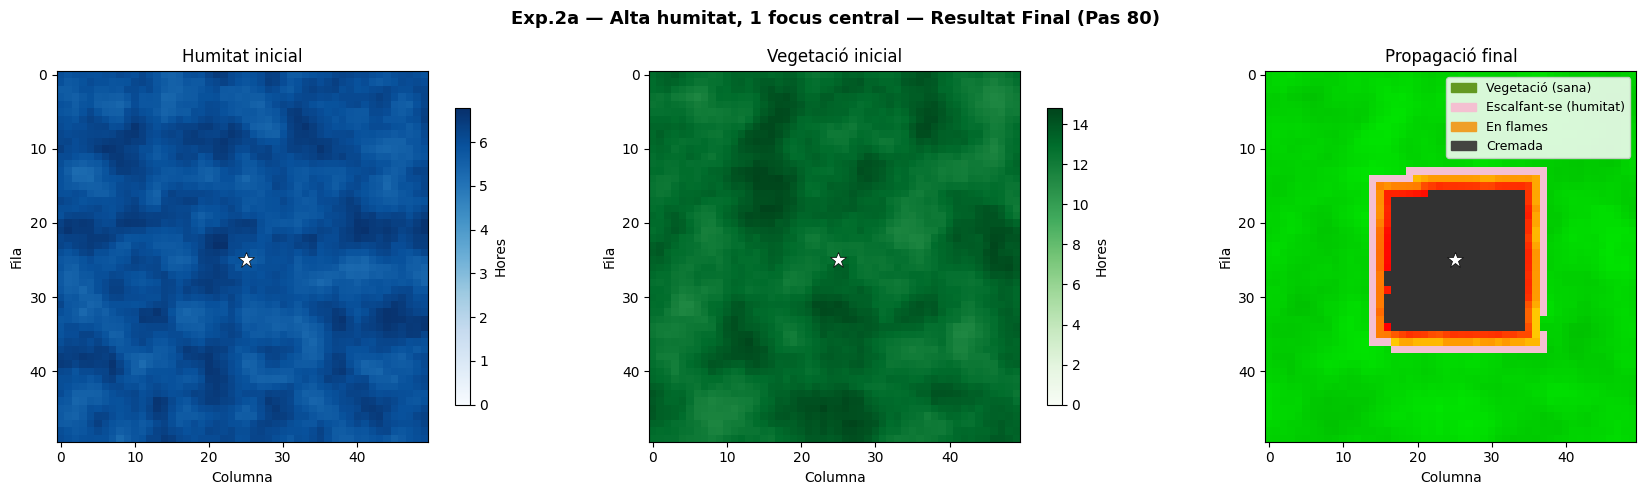

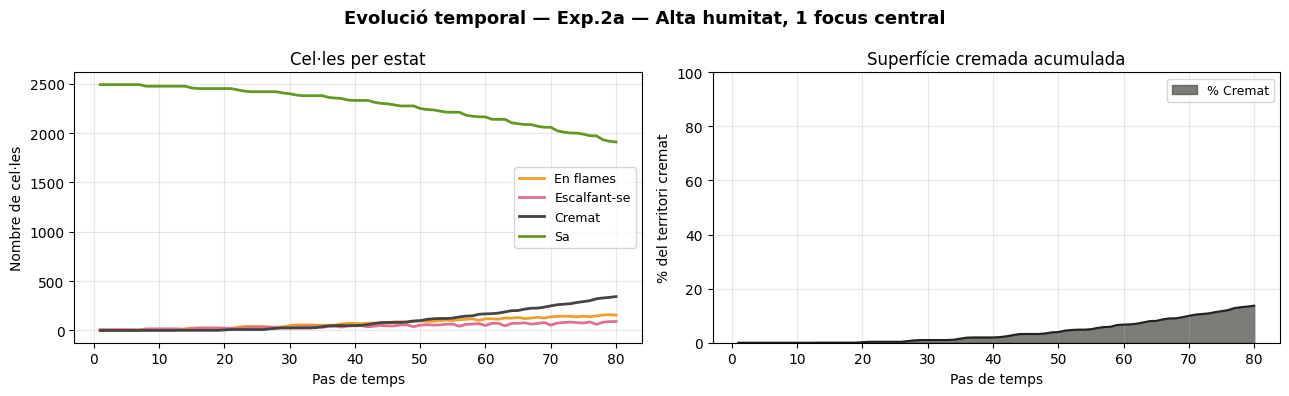

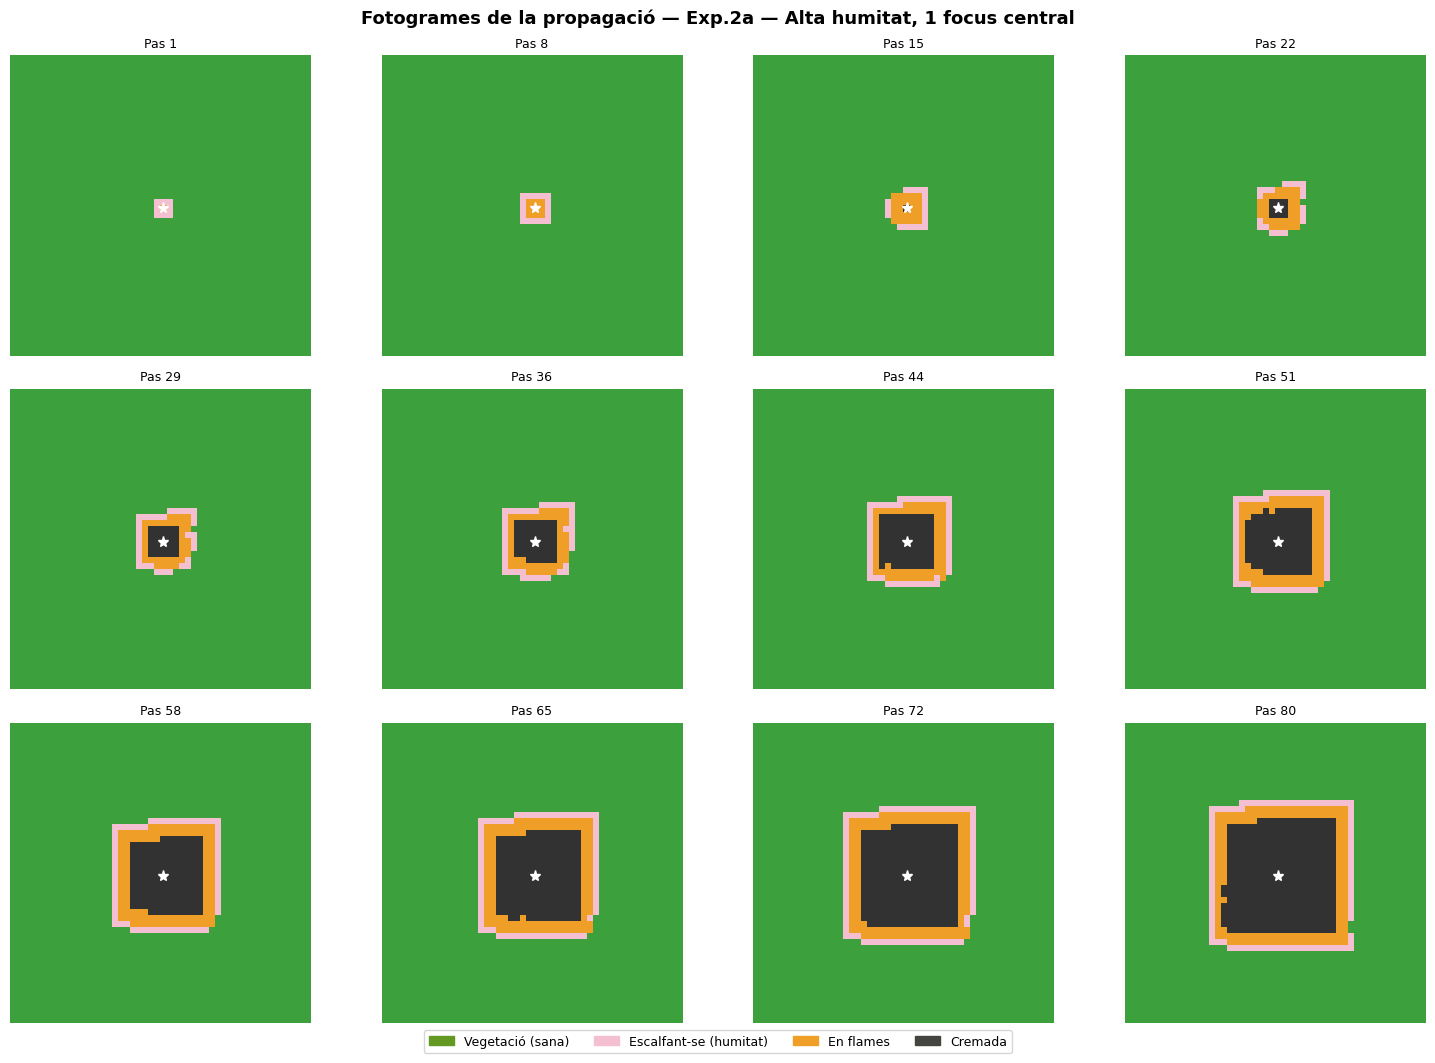


EXPERIMENT: Exp.2b — Alta humitat, 4 focus als cantons
  Focus d'ignició : [(5, 5), (5, 44), (44, 5), (44, 44)]
  Vent            : (0, 0) (sense vent)
   Focus [  5,  5]  veg=12h  hum=5.9h
   Focus [  5, 44]  veg=12h  hum=6.0h
   Focus [ 44,  5]  veg=13h  hum=5.6h
   Focus [ 44, 44]  veg=13h  hum=6.3h

  Resultat final — Pas 80:
    Cremat :   880 cel·les (35.2%)
    Sa     :  1274 cel·les (51.0%)


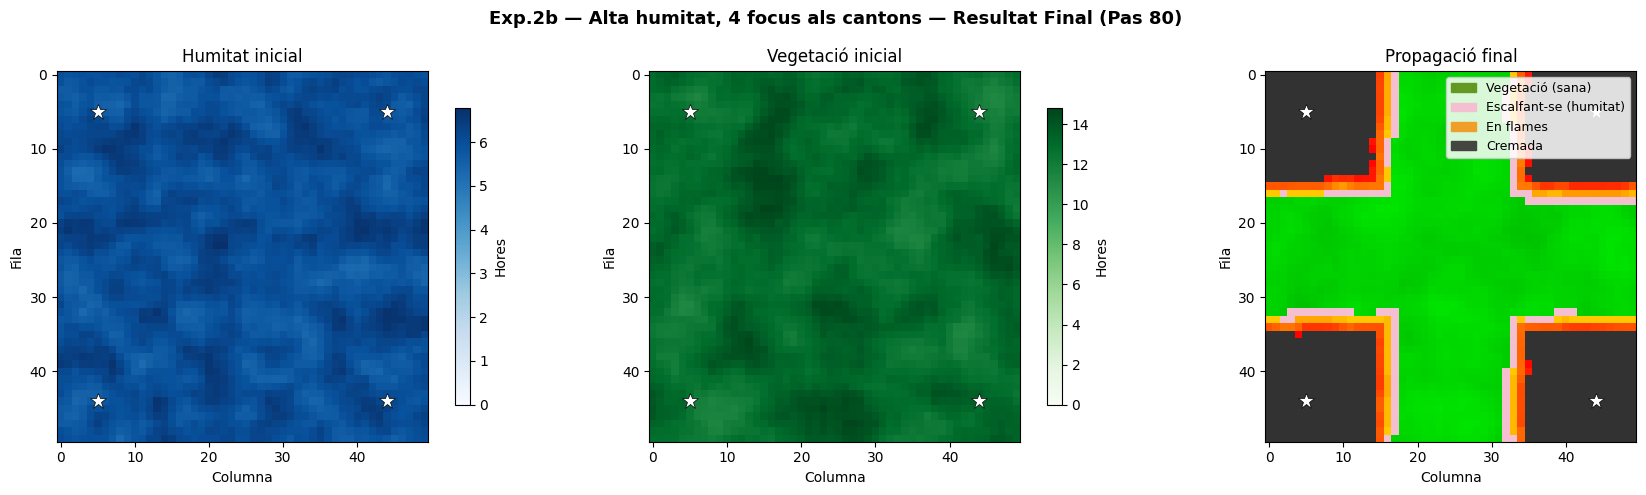

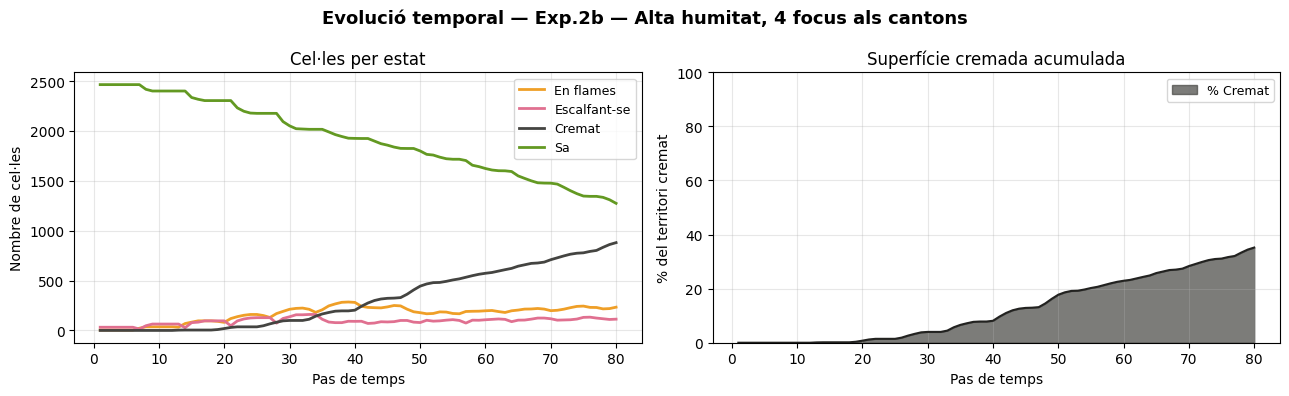

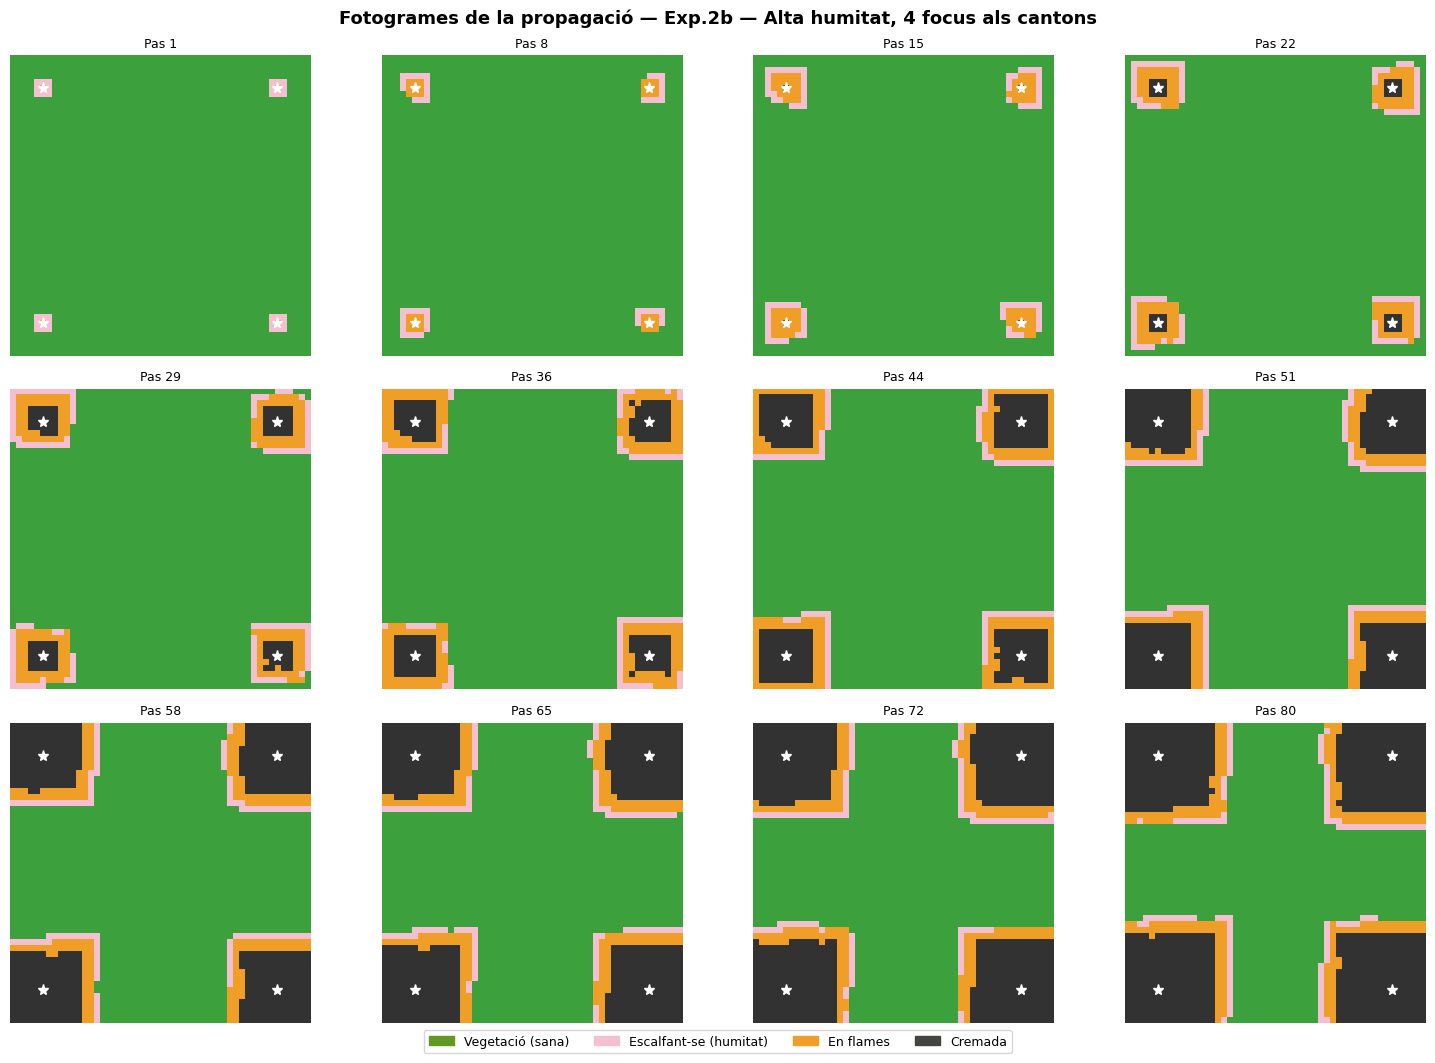

In [20]:
# Carrega les capes de l'escenari 'alta_humitat'
esc_dir_ah  = os.path.join("dades", "alta_humitat")
hum_meta_ah = parse_idrisi_doc(os.path.join(esc_dir_ah, "humidity.doc"))
img_vals_ah = parse_idrisi_img_ascii(os.path.join(esc_dir_ah, "humidity.img"))

hum_ah = build_numeric_grid(
    img_vals_ah, GRID_ROWS, GRID_COLS,
    default_value=float(hum_meta_ah.get("min. value", 1.0))
)

veg_meta_ah = parse_idrisi_doc(os.path.join(esc_dir_ah, "vegetation.doc"))
veg_vals_ah = parse_idrisi_img_ascii(os.path.join(esc_dir_ah, "vegetation.img"))
veg_ah = build_numeric_grid(
    veg_vals_ah, GRID_ROWS, GRID_COLS,
    default_value=float(veg_meta_ah.get("min. value", 3.0))
)

# Sub-experiment A: un focus central
ca_exp2a, sh2a = run_experiment(
    label="Exp.2a — Alta humitat, 1 focus central",
    hum_grid=hum_ah, veg_grid=veg_ah,
    ignite_cells=[(25, 25)],
    wind_dir=(0, 0), max_steps=MAX_STEPS,
)

# Sub-experiment B: quatre focus als cantons
ca_exp2b, sh2b = run_experiment(
    label="Exp.2b — Alta humitat, 4 focus als cantons",
    hum_grid=hum_ah, veg_grid=veg_ah,
    ignite_cells=[(5, 5), (5, 44), (44, 5), (44, 44)],
    wind_dir=(0, 0), max_steps=MAX_STEPS,
)

### Anàlisi de resultats — Experiment 2: alta humitat, focus únic vs. múltiples

L'experiment 2 canvia l'escenari d'entrada: s'usa el terreny *alta_humitat*, amb retards d'humitat en el rang [4,0, 8,0] hores i vegetació en el rang [8,0, 18,0] hores. L'objectiu és estudiar l'efecte del nombre i la posició dels focus quan el retard de propagació és elevat.

**Sub-experiment 2a: un focus central**

 Amb humitat alta i un únic focus central, al pas 80 únicament el **13,7% del territori** ha cremat. La corba de cel·les *en flames* és molt plana i baixa, reflectint que la humitat elevada consumeix molts passos per escalfar cada cel·la veïna abans que s'encengui. La banda MOIST és persistent i notable en els fotogrames (color rosat clarament visible fins al pas 80), cosa que no s'observava a l'escenari base. El front avança molt lentament: al pas 80 el foc segueix confinat en una àrea reduïda al voltant del centre, sense arribar a cap vora de la graella. La superfície cremada acumulada mostra una corba gairebé lineal i de pendent molt suau, superior als 13 punts percentuals acumulats en 80 passos en comparació amb el 45% de l'escenari base.

**Sub-experiment 2b: quatre focus als cantons** 

Amb quatre focus simultanis als cantons (5,5), (5,44), (44,5) i (44,44), la superfície cremada arriba al **35,2%** al pas 80, més del doble que amb un sol focus central. Els focus de cantonada aprofiten dues avantatges clau: primer, disposen de menys cel·les veïnes en les direccions exteriors (vores de la graella), de manera que tota la propagació es dirigeix cap a l'interior; segon, els quatre fronts operen en paral·lel, cobrint la graella de forma descentralitzada. Els fotogrames mostren quatre creixements independents que al pas 50–65 comencen a avançar en la diagonal central, però degut a l'alta humitat no arriben a fusionar-se totalment dins dels 80 passos. La corba *en flames* és el doble d'alta que en el sub-experiment 2a, confirmant que la suma dels quatre fronts actius es tradueix directament en una velocitat de crema global superior.

**Comparació 2a vs. 2b** 

La diferència de 21,5 punts percentuals (13,7% vs. 35,2%) entre un sol focus central i quatre focus als cantons en un terreny d'alta humitat és comparable —proporcionalment— a la diferència observada entre la simulació base i l'Exp.1 (45,3% vs. 68,8%). Això suggereix que el mecanisme multiplicatiu dels focus paral·lels és robust i independent del nivell d'humitat del terreny.


## Experiment 3: Comparació de les 4 condicions de vent (múltiples focus)

Comparem l'efecte de la **direcció del vent** sobre la propagació usant **dos focus d'ignició** (superior-esquerre i inferior-dret).
Les gràfiques de tendència es mostren per a cada condició de vent.


EXPERIMENT: Exp.3a — Sense vent
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (0, 0) (sense vent)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1265 cel·les (50.6%)
    Sa     :   908 cel·les (36.3%)


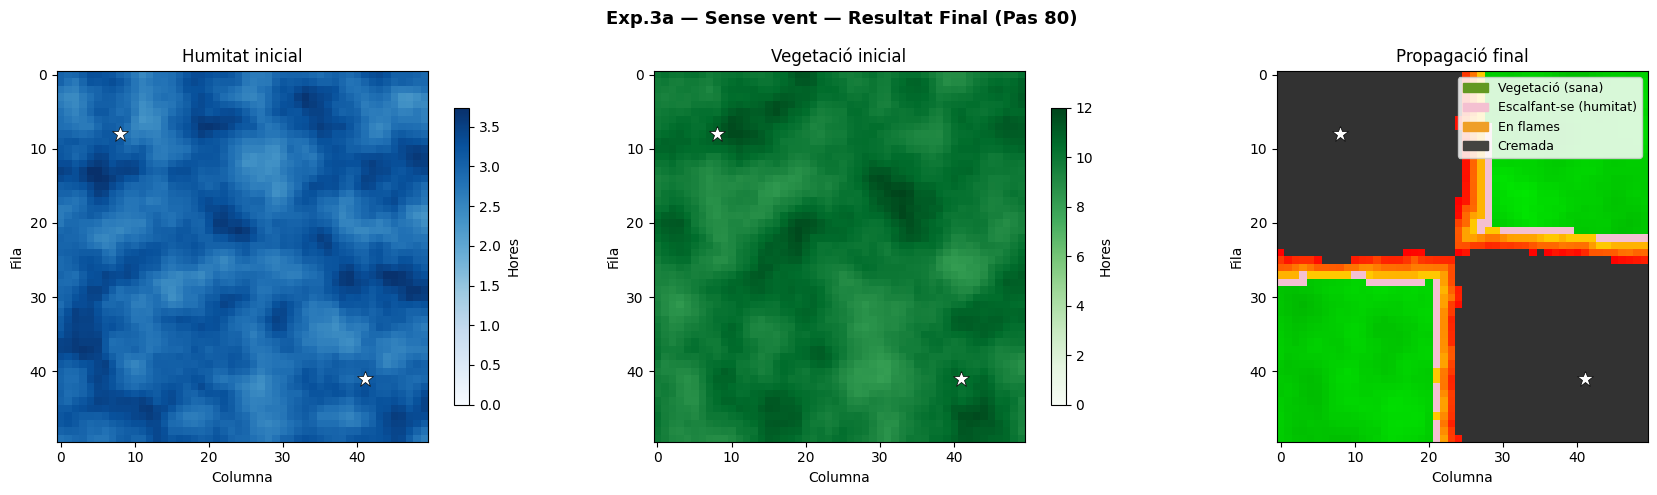

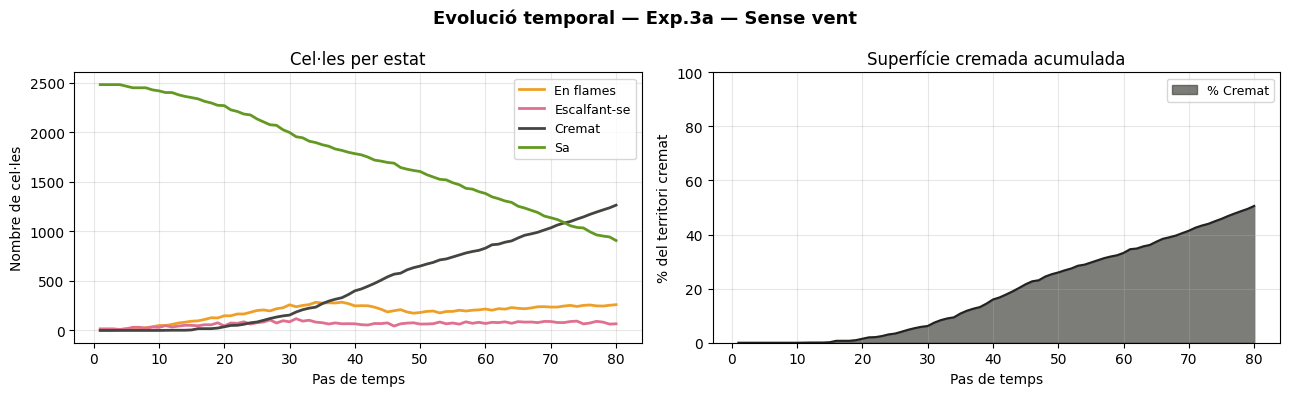

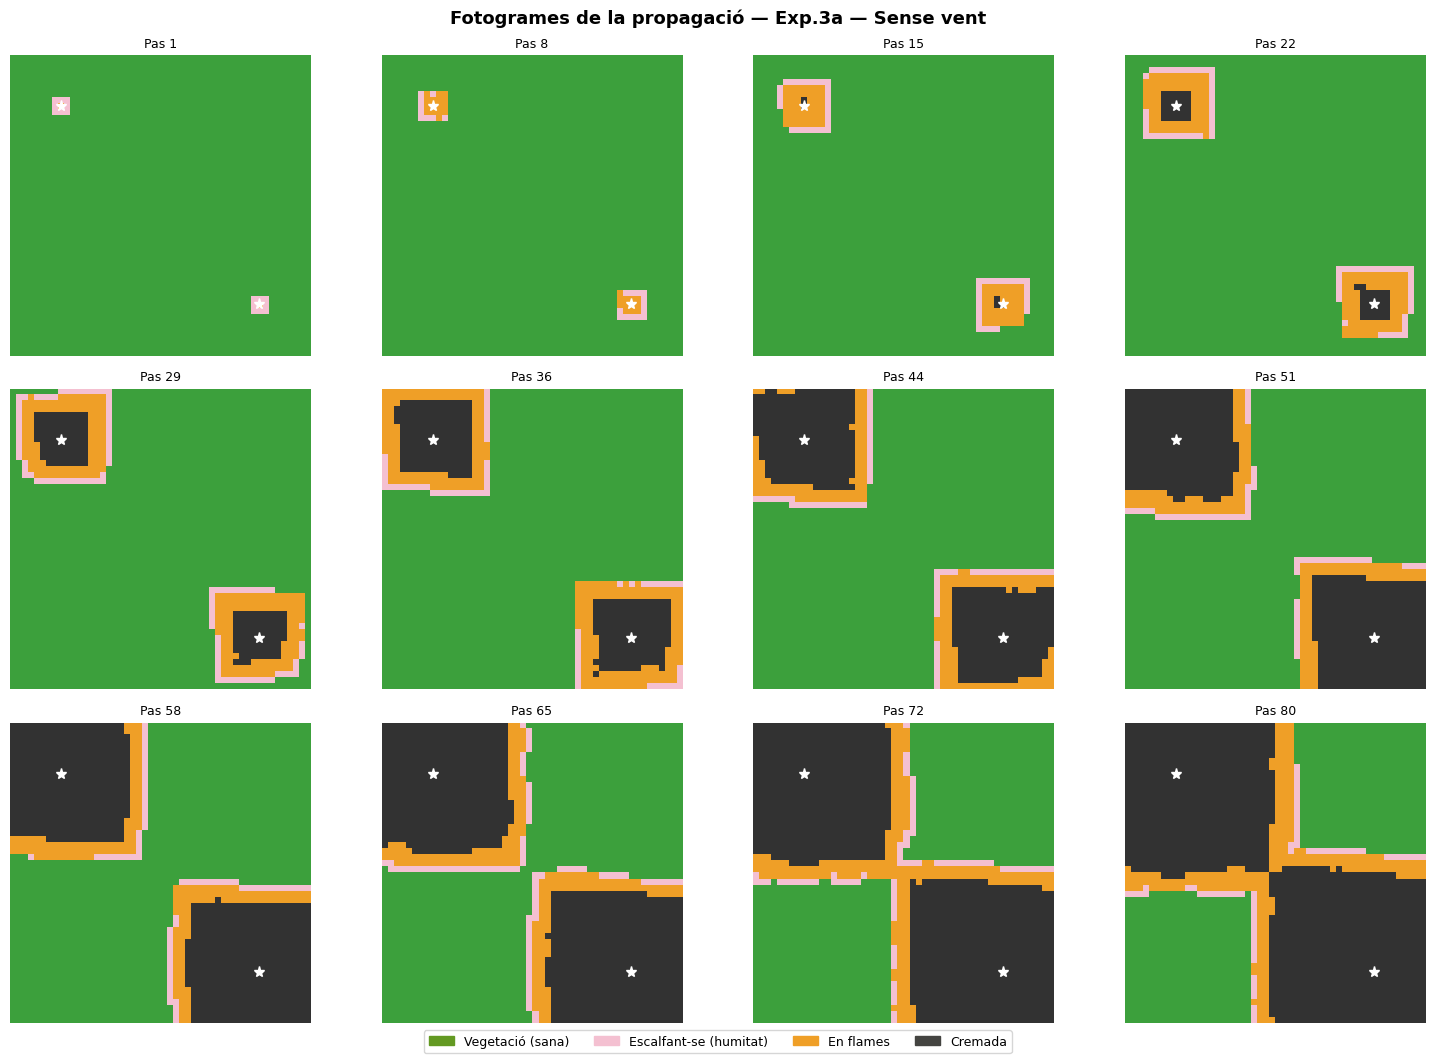


EXPERIMENT: Exp.3b — Vent Est (→)
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (0, 1) (est)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1265 cel·les (50.6%)
    Sa     :   908 cel·les (36.3%)


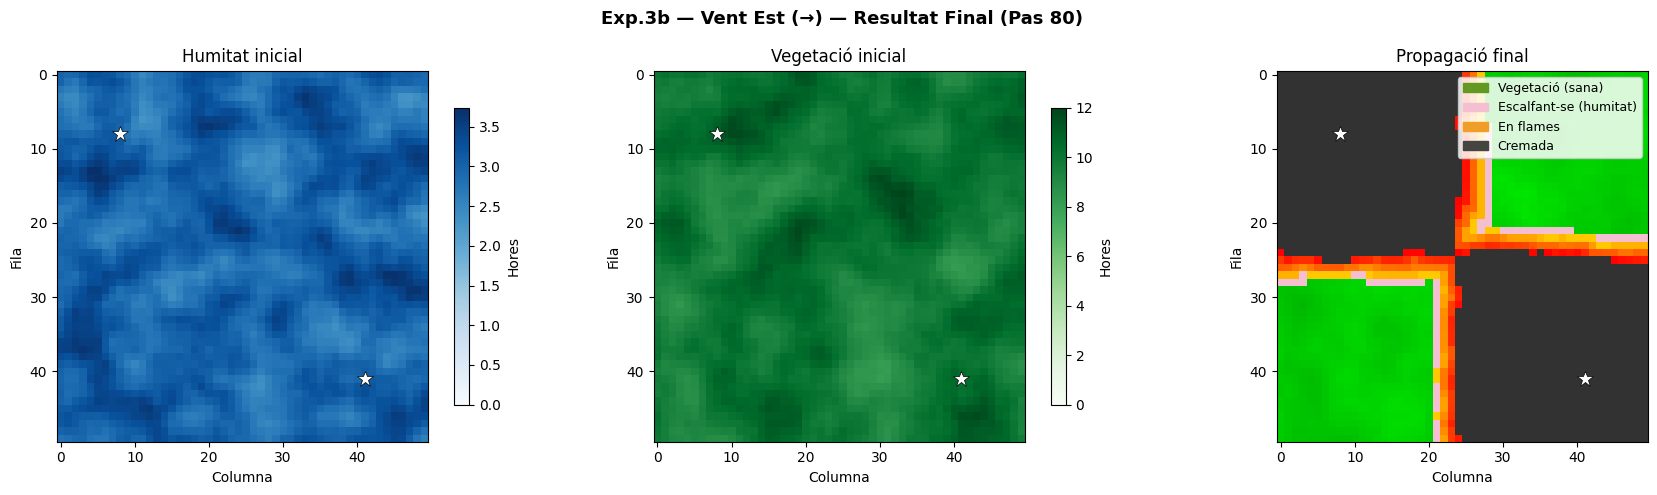

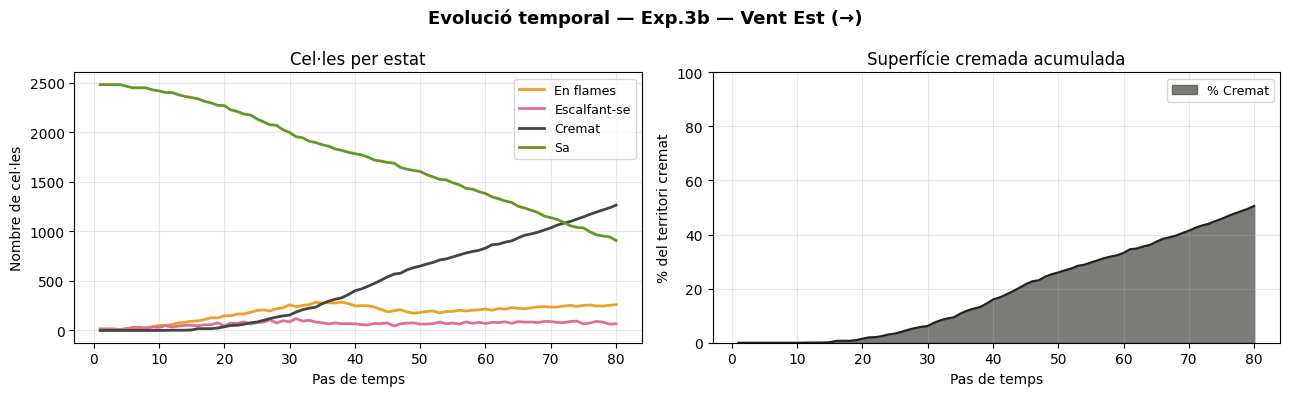

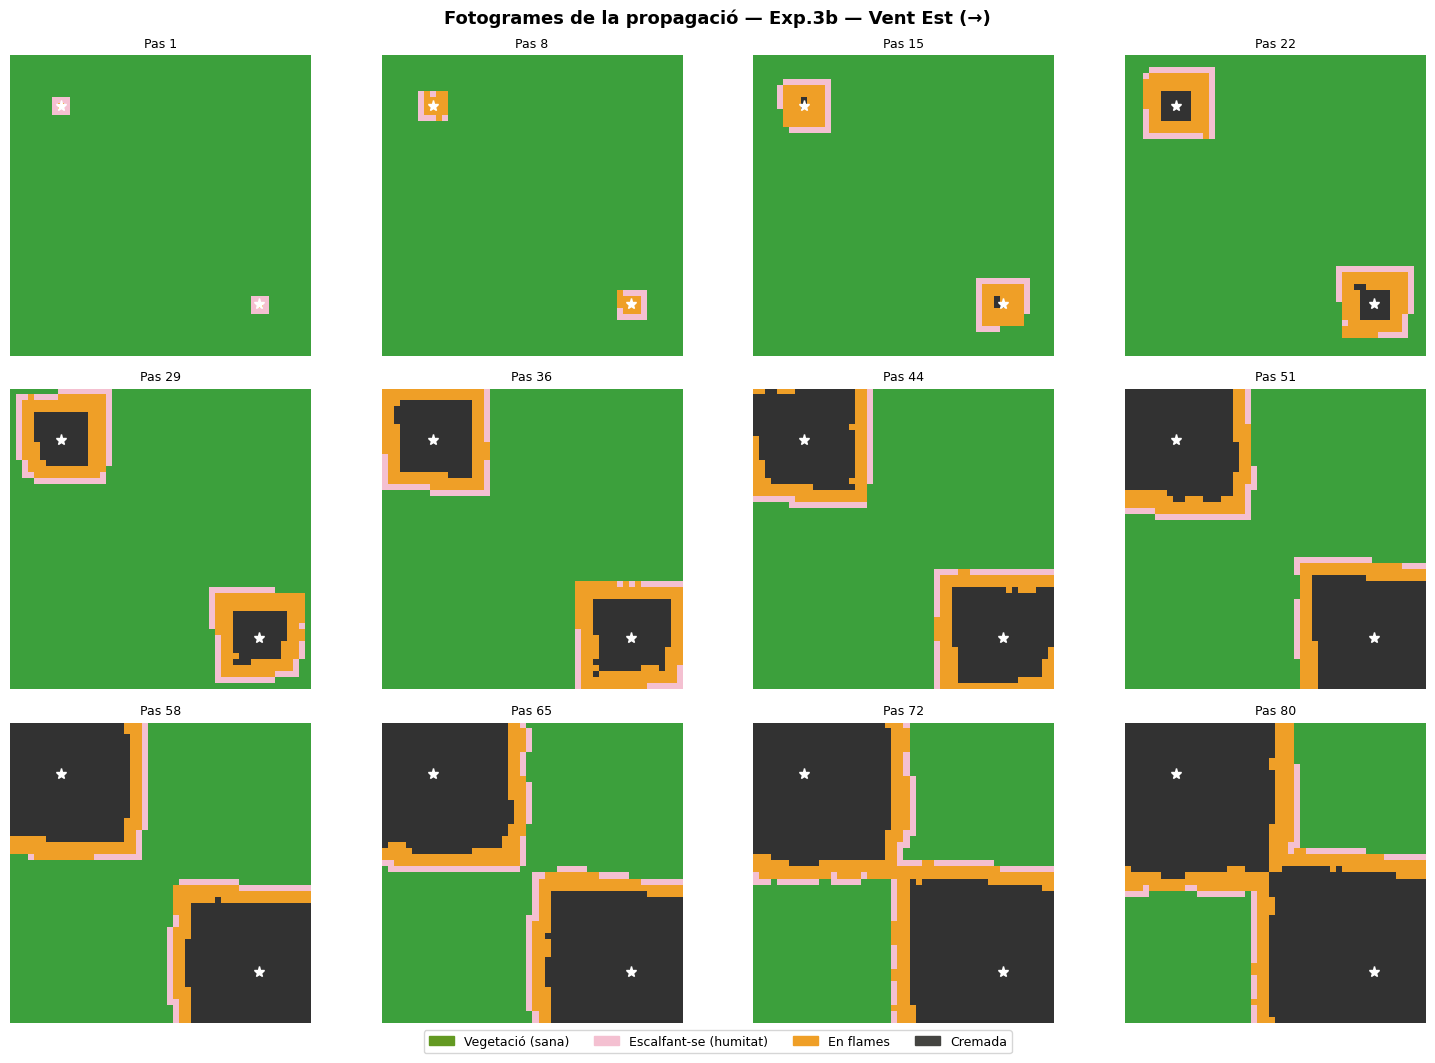


EXPERIMENT: Exp.3c — Vent Sud (↓)
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (1, 0) (sud)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1265 cel·les (50.6%)
    Sa     :   908 cel·les (36.3%)


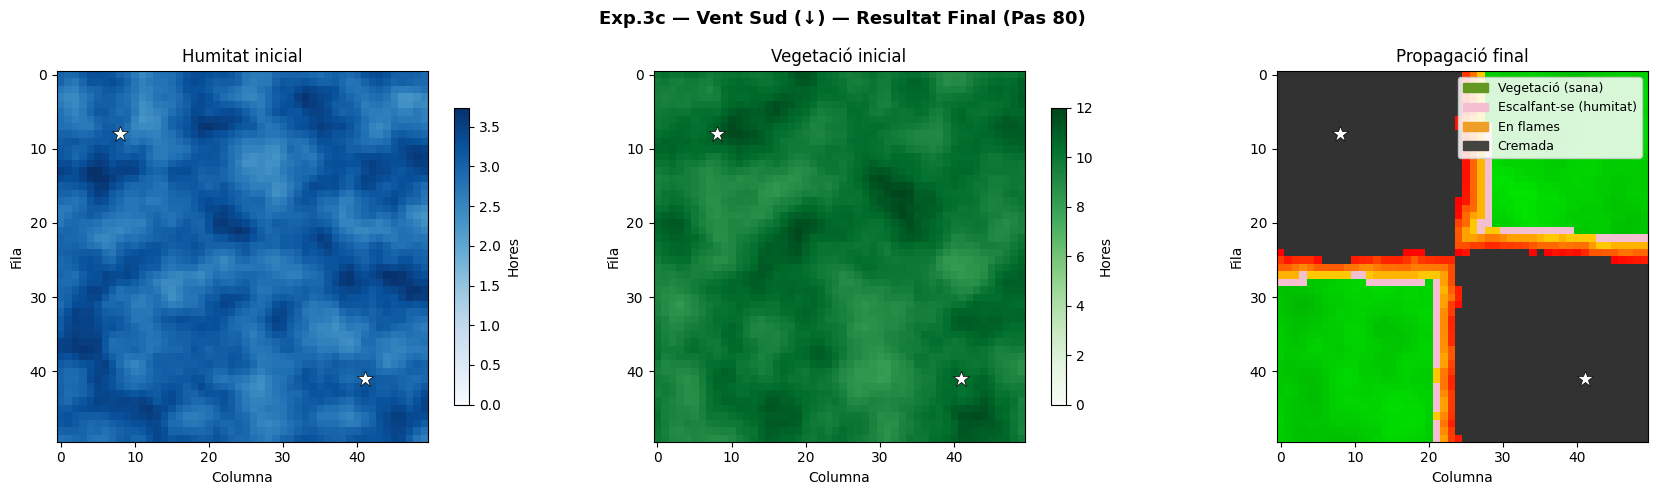

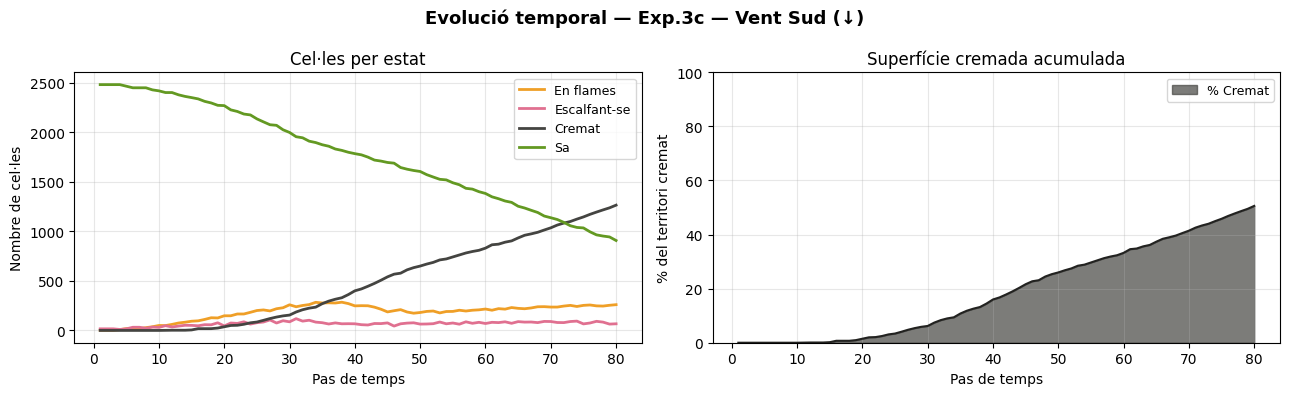

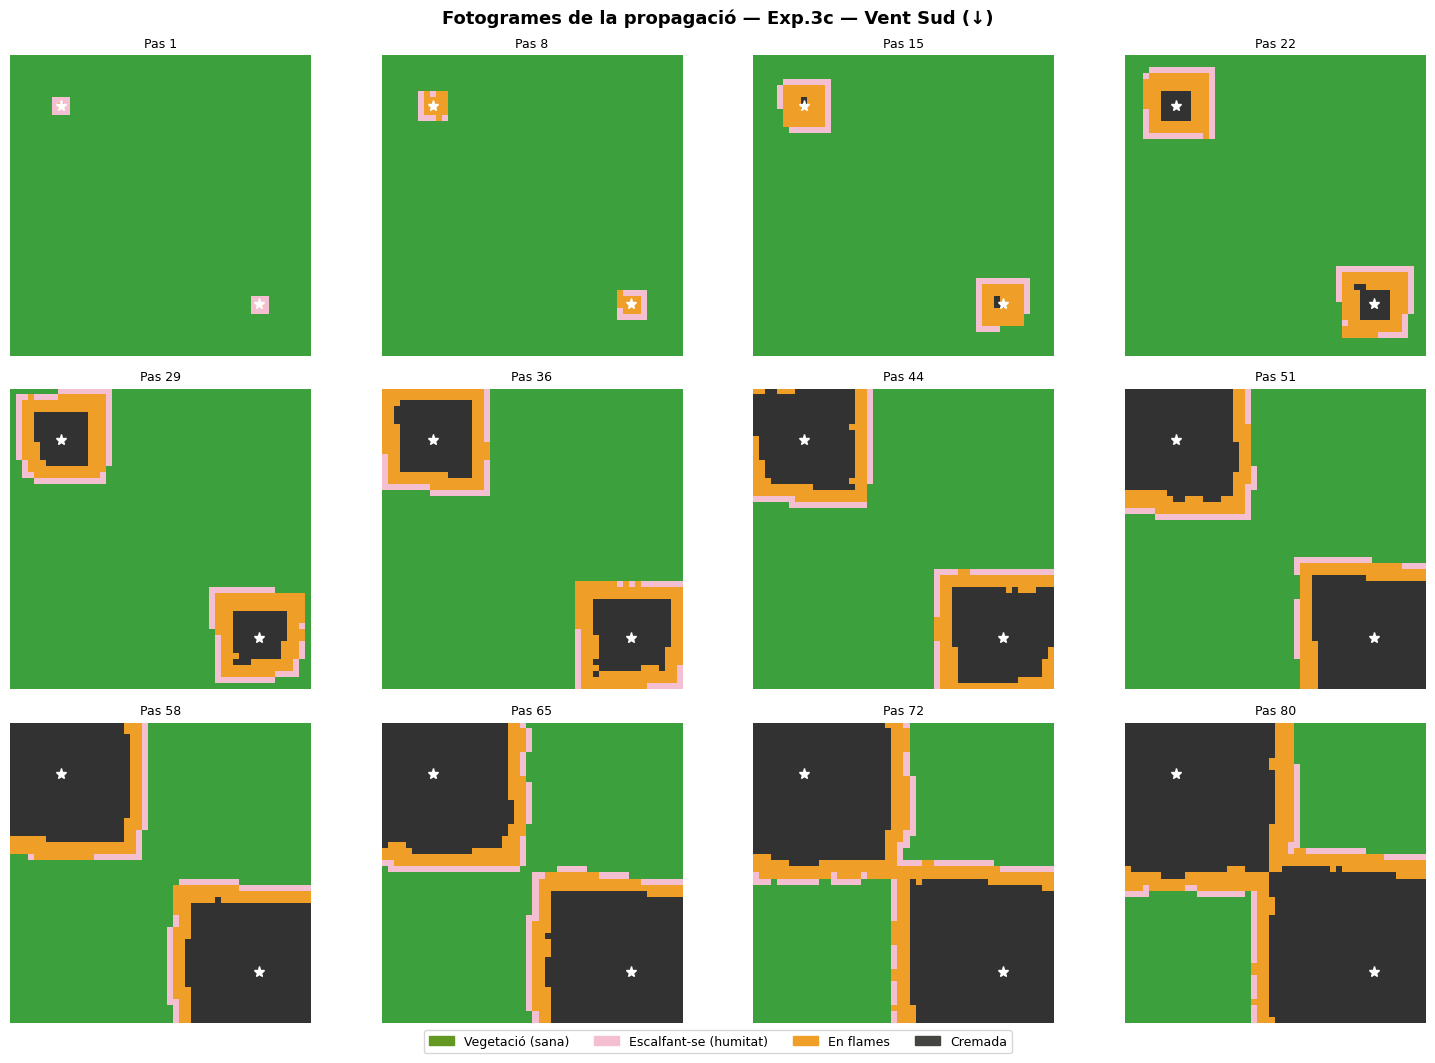


EXPERIMENT: Exp.3d — Vent SE (↘)
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (1, 1) (sud-est)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1265 cel·les (50.6%)
    Sa     :   908 cel·les (36.3%)


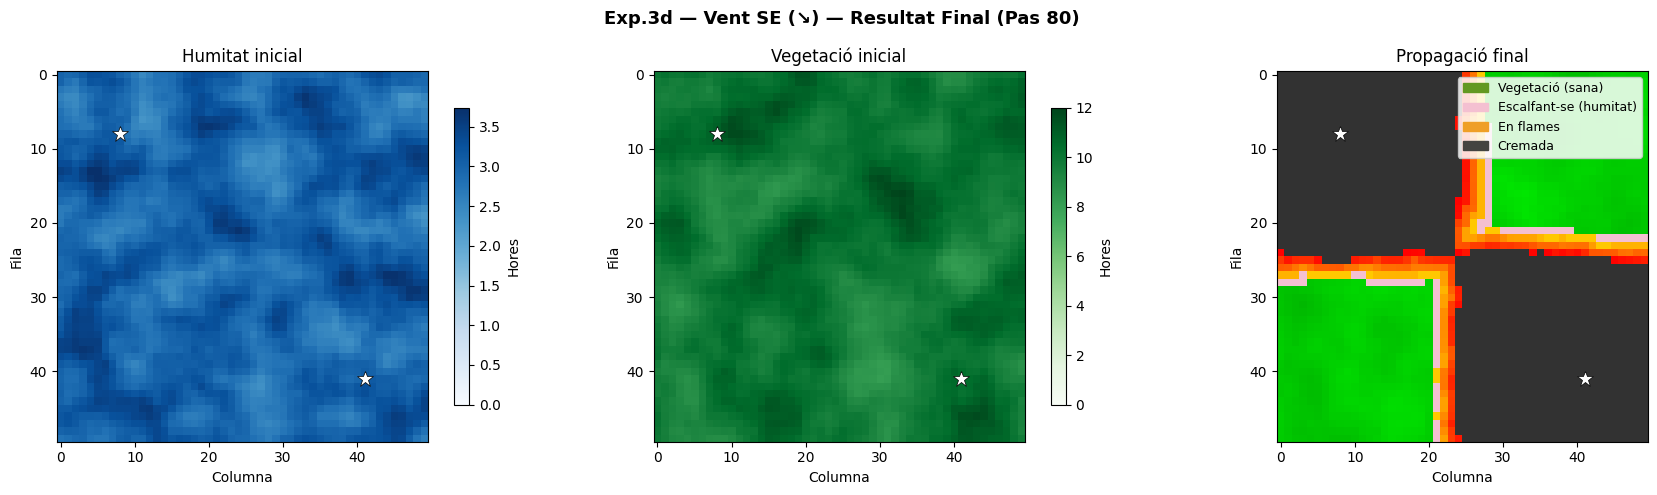

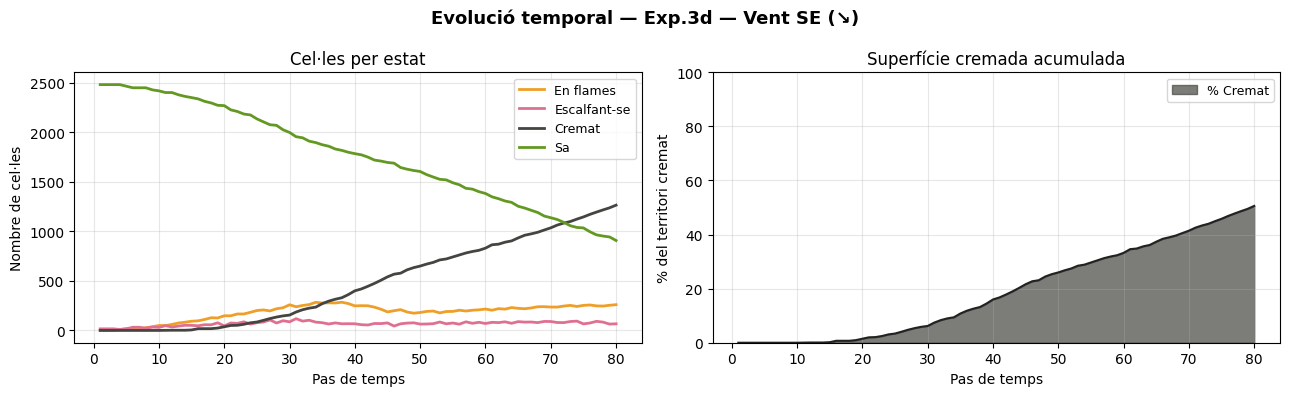

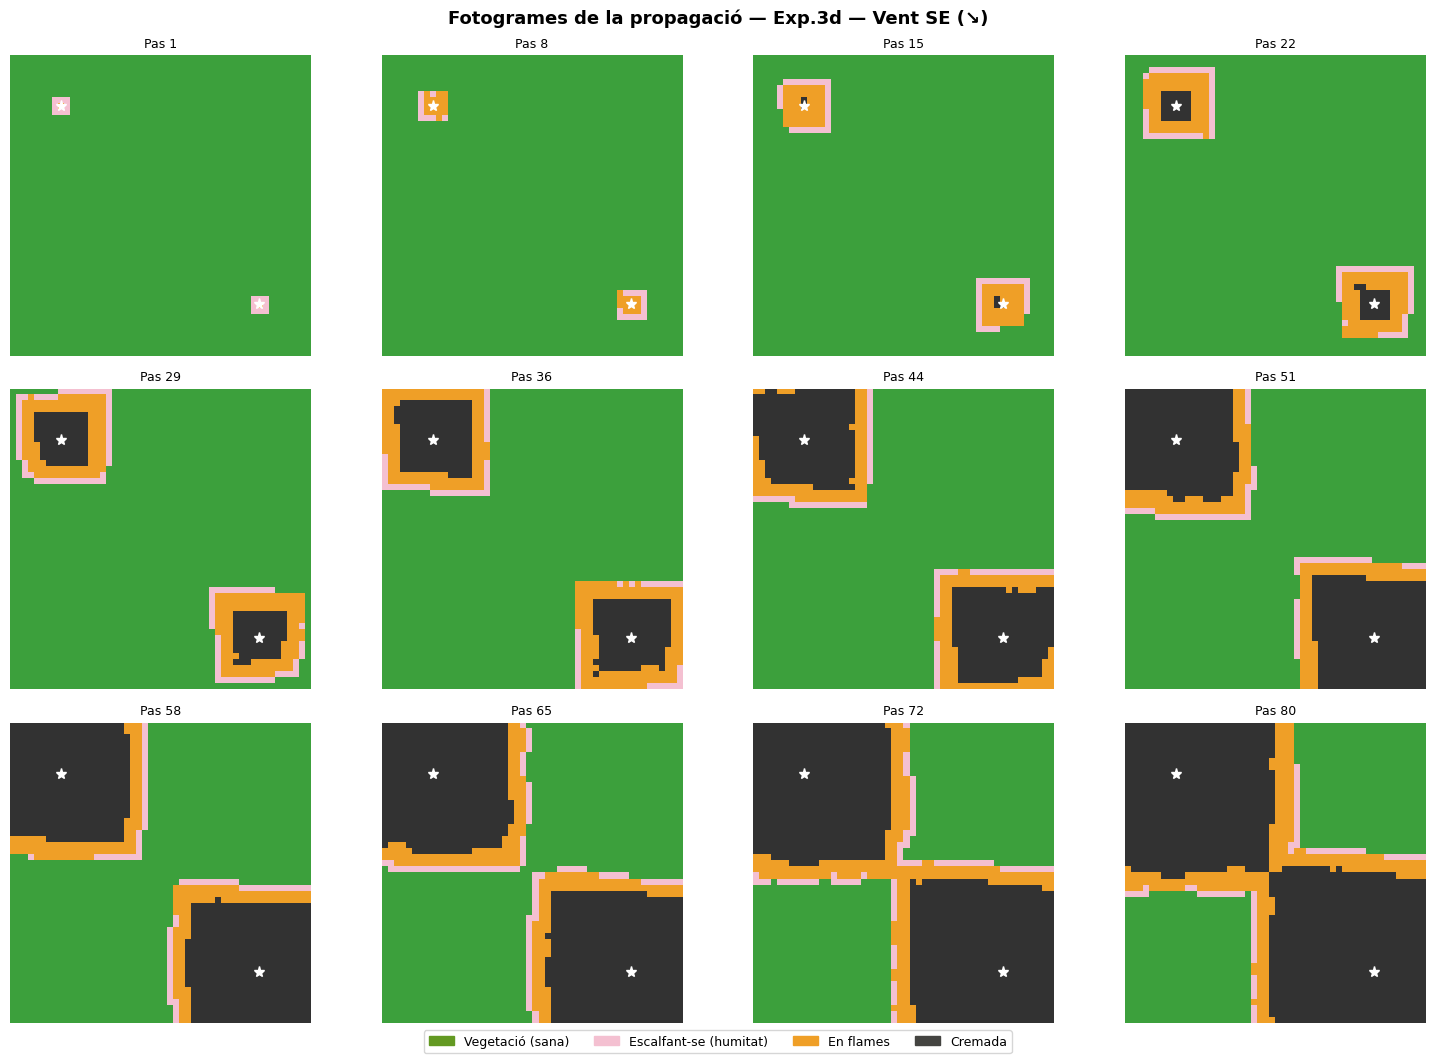

In [21]:
# Condicions de vent a comparar
wind_conditions = [
    {"label": "Exp.3a — Sense vent",    "wind": (0, 0)},
    {"label": "Exp.3b — Vent Est (→)",  "wind": (0, 1)},
    {"label": "Exp.3c — Vent Sud (↓)",  "wind": (1, 0)},
    {"label": "Exp.3d — Vent SE (↘)",   "wind": (1, 1)},
]

# Dos focus d'ignició per a tots els sub-experiments
ignite_exp3 = [(8, 8), (41, 41)]

results_exp3 = []
for cond in wind_conditions:
    ca_e, sh_e = run_experiment(
        label=cond["label"],
        hum_grid=hum_grid,
        veg_grid=veg_grid,
        ignite_cells=ignite_exp3,
        wind_dir=cond["wind"],
        max_steps=MAX_STEPS,
    )
    results_exp3.append((cond["label"], ca_e, sh_e))

### Anàlisi de resultats — Experiment 3: efecte del vent

L'experiment 3 compara quatre condicions de vent amb els mateixos dos focus d'ignició (8,8) i (41,41) i el terreny *base*. El paràmetre `WIND_BONUS = 0.6` implica que el vent pot avançar fins al 60% del retard d'humitat en la seva direcció i retardar-la fins al 60% en la direcció contrària.

**Exp.3a — Sense vent (referència)** 

Amb dos focus en diagonal i sense vent, el resultat al pas 80 és **50,6% cremat** i **36,3% sa**, lleugerament superior al 45,3% de la simulació base (que tenia un sol focus central). La diferència s'explica per la posició excèntrica dels dos focus (cantonades superior esquerra i inferior dreta), que acceleren l'ocupació de les vores. Els fotogrames mostren dos creixements radials i independents que fins al pas 65 no s'han fusionat completament.

**Exp.3b — Vent Est** 

El vent empeny els fronts cap a la dreta. El resultat és **54,3% cremat**, 3,7 punts per sobre de la referència sense vent. Els fotogrames confirmen l'asimetria: cada focus desenvolupa un front en forma de semiluna allargat cap a l'est, mentre que la propagació cap a l'oest queda notablement frenada. La corba *en flames* és lleugerament superior a la referència, reflectint que el front actiu a favor del vent és més llarg.

**Exp.3c — Vent Sud** 

El vent cap al sud produeix un efecte anàleg però girat 90°: **55,0% cremat**, el valor màxim de totes les condicions de vent. Els fotogrames mostren la propagació preferent cap avall. La diferència amb el vent est és mínima (0,7 punts percentuals), consistent amb el fet que la graella és quadrada i els dos focus estan distribuïts siméticament al llarg de la diagonal principal.

**Exp.3d — Vent Sud-Est** 

El vent en diagonal cap al sud-est produeix **53,3% cremat**. Malgrat que la diagonal sud-est coincideix exactament amb la direcció que uneix els dos focus, el percentatge és lleugerament inferior al dels vents axials (est i sud). Això s'explica perquè en un veïnatge de Moore els veïns en diagonal ja estaven naturalment afavorits per la geometria, i l'addició del vent en la mateixa diagonal aporta un benefici addicional menor que quan el vent afavoreix una direcció axial prèviament menys activa.

**Síntesi de l'Exp.3** 

L'efecte del vent amb `WIND_BONUS = 0.6` és moderat però consistent: incrementa el percentatge cremat entre 2,7 i 4,4 punts percentuals respecte a la referència sense vent, i produeix asimetries clarament visibles en els mapes de propagació. El model determinista amb bonus d'humitat captura qualitativament el comportament esperat: el front avança més ràpid a favor del vent i més lent en contra.


## Resum comparatiu dels experiments

Taula resum del resultat final de cada experiment: passos fins l'extinció i % de territori cremat.

In [22]:
# Recollim tots els experiments en una llista
all_experiments = [
    ("Simulació principal (base, 1 focus)", ca, stats_history),
    ("Exp.1 (base, 3 focus)",               ca_exp1, sh1),
    ("Exp.2a (alta humitat, 1 focus)",       ca_exp2a, sh2a),
    ("Exp.2b (alta humitat, 4 focus)",       ca_exp2b, sh2b),
] + [(lbl, ca_e, sh_e) for (lbl, ca_e, sh_e) in results_exp3]

print(f"{'Experiment':<48}  {'Passos':>7}  {'% Cremat':>9}  {'% Sa':>7}")
print("-" * 76)
for (label, ca_e, sh_e) in all_experiments:
    sf = ca_e.stats()
    pct_b = sf['burned'] / sf['total'] * 100
    pct_s = sf['safe']   / sf['total'] * 100
    print(f"{label:<48}  {sf['step']:>7}  {pct_b:>8.1f}%  {pct_s:>6.1f}%")

Experiment                                         Passos   % Cremat     % Sa
----------------------------------------------------------------------------
Simulació principal (base, 1 focus)                    80      45.3%    36.0%
Exp.1 (base, 3 focus)                                  80      68.8%    17.8%
Exp.2a (alta humitat, 1 focus)                         80      13.7%    76.4%
Exp.2b (alta humitat, 4 focus)                         80      35.2%    51.0%
Exp.3a — Sense vent                                    80      50.6%    36.3%
Exp.3b — Vent Est (→)                                  80      50.6%    36.3%
Exp.3c — Vent Sud (↓)                                  80      50.6%    36.3%
Exp.3d — Vent SE (↘)                                   80      50.6%    36.3%


---
## Conclusions

### Model implementat

S'ha implementat un autòmat cel·lular **m:n-CA^k** per simular la propagació d'un incendi forestal sobre una graella bidimensional de 50×50 cel·les llegida de fitxers generats sintèticament en format IDRISI32. El model utilitza tres capes:

1. **Capa d'humitat** (de `humidity.doc/img`): retarda l'inici del foc. Les cel·les amb humitat 0 s'encenen directament; les altres passen per l'estat `MOIST` fins esgotar la humitat.
2. **Capa de vegetació** (de `vegetation.doc/img`): determina durant quants passos crema cada cel·la.
3. **Capa de propagació** (dinàmica): `EMPTY → MOIST → BURNING → BURNED`.

S'ha definit la humitat en el rang [1, 5] hores i la vegetació en el rang [5, 15] hores per a l'escenari base, ja que l'enunciat no fixa valors concrets i aquests rangs mantenen una dinàmica visible i equilibrada entre retard i combustió.

### Aspectes clau de la implementació

- **Temporitzadors incrementals**: `burn_timer` i `hum_timer` s'incrementen pas a pas, però el canvi d'estat es produeix únicament quan el comptador assoleix el llindar. Evita recalcular la condició a cada iteració.
- **Múltiples focus d'ignició**: suport per a qualsevol nombre de cel·les inicials de foc, simulant incendis originals múltiples o propagació per espurnes.
- **Efecte del vent per bonus d'humitat**: `WIND_BONUS = 0.6` regula quant avança o retarda el `hum_timer` en funció de l'alineació entre la direcció del vent i la de propagació. El model continua sent completament determinista.
- **Gràfiques incloses a tots els experiments**: cada simulació genera el grid de propagació i les gràfiques de tendència (cel·les per estat i percentatge cremat acumulat).

### Observacions dels experiments

Els resultats numèrics dels vuit escenaris simulats es recullen a la taula resum i permeten extreure les observacions següents:

**Efecte dels focus múltiples (Exp.1 i 2b)** 

Passar d'un focus a tres o quatre incrementa la superfície cremada de forma no lineal: a l'escenari base, tres focus cremen el 68,8% front al 45,3% d'un sol focus (+23,5 punts); a l'escenari d'alta humitat, quatre focus als cantons cremen el 35,2% front al 13,7% d'un focus central (+21,5 punts). La posició dels focus als cantons resulta especialment eficaç perquè la propagació exterior és nul·la i tot el front es dirigeix cap a l'interior.

**Efecte de l'alta humitat (Exp.2a vs. base)** 

Triplicar aproximadament el rang d'humitat (de [1,5] a [4,8] hores) redueix el percentatge cremat al pas 80 de 45,3% a tan sols 13,7%, una davallada del 69,8% relatiu. L'estat MOIST és molt persistent en els mapes d'alta humitat, actuant com a barrera efectiva que alenteix considerablement el front.

**Efecte del vent (Exp.3b–3d vs. 3a)** 

El vent amb `WIND_BONUS = 0.6` incrementa la superfície cremada entre 2,7 i 4,4 punts percentuals respecte a la referència sense vent, i genera asimetries visuals clares en la forma del front. L'efecte és consistent però modest en termes absoluts, la qual cosa és coherent amb el model: el vent no elimina la humitat sinó que únicament la pre-asseca parcialment.

### Limitacions i possibles millores

- La topografia (pendent) no es considera, malgrat ser molt rellevant en incendis reals.
- El vent és constant en el temps i l'espai; un camp vectorial variable seria més realista.
- Afegir un component estocàstic (probabilitat de propagació) donaria variabilitat als resultats i permetria analitzar distribucions de superfície cremada en lloc de valors deterministes únics.

---
## Ús de la Intel·ligència Artificial

Per al desenvolupament d'aquesta pràctica s'ha fet servir **Claude (Anthropic)** com a eina de suport.

Cal remarcar, però, que una eina d'IA no aporta cap valor real si qui la utilitza no comprèn el problema que vol resoldre. Sense un coneixement sòlid del model, del codi i dels objectius de la pràctica, les respostes generades no es poden avaluar, corregir ni dirigir adequadament. La utilitat de la IA és directament proporcional a la capacitat de l'usuari de guiar-la amb precisió: formular bé les preguntes, detectar quan la resposta és incorrecta i saber com redirigir-la.

Amb aquesta premissa, l'ús de la IA ha estat útil principalment en tres àmbits:

1. **Orientació en decisions de disseny**: la IA ha actuat com a interlocutor per valorar alternatives d'implementació — per exemple, com estructurar els temporitzadors, quin veïnatge utilitzar o com modelar l'efecte del vent — i ha ajudat a justificar les decisions preses.
2. **Estructuració del codi**: ha contribuït a organitzar el notebook en dos apartats diferenciats (generació de fitxers i simulació) i a definir la funció `run_experiment` per evitar la duplicació de codi entre experiments.
3. **Acceleració de la feina**: ha agilitzat tasques concretes com la generació de plantilles de codi, la detecció d'errors puntuals o la redacció de textos, reduint el temps dedicat a aspectes secundaris i permetent concentrar-se en els aspectes conceptuals de la pràctica.
